# 🎙️ Voice Cloning From Scratch — A Deep Learning Journey

> **Who is this for?** Someone with a solid DL background (images/tabular) who wants to understand voice cloning from first principles — without touching pretrained models yet.
>
> **What will you build?** A full voice cloning pipeline: raw audio → features → speaker encoder → synthesizer → vocoder. Every component built and trained from scratch so you *understand* what it does.
>
> **Interview promise:** After this notebook, you can confidently explain MFCCs, spectrograms, encoder-decoder TTS architectures, and why voice cloning is hard — all from first principles.

---

## 📖 Table of Contents
1. [The Big Picture — What is Voice Cloning?](#1)
2. [Audio Fundamentals — Sound as Data](#2)
3. [Feature Engineering — From Waveform to Spectrogram](#3)
4. [MFCCs — The "Images" of Audio](#4)
5. [Speaker Embeddings — Capturing Voice Identity](#5)
6. [Text-to-Speech (TTS) — The Synthesizer](#6)
7. [The Vocoder — Converting Features Back to Audio](#7)
8. [Putting It All Together — The Full Pipeline](#8)
9. [Training Tips & What to Try Next](#9)

---

<a id='1'></a>
## 🧠 Section 1 — The Big Picture: What is Voice Cloning?

### What problem are we solving?

Given a **short audio clip of Person X** speaking (say 5 seconds), we want to synthesize **Person X saying any arbitrary text** — in their voice, with their accent, their rhythm, their timbre.

### The three-component architecture

Every modern voice cloning system has **three modules**:

```
┌─────────────────────────────────────────────────────────┐
│                   VOICE CLONING PIPELINE                │
│                                                         │
│  Audio Clip  ──►  [SPEAKER ENCODER]  ──►  Speaker Vec  │
│                                               │         │
│  Text Input  ──►  [SYNTHESIZER/TTS]  ◄────────┘         │
│                          │                              │
│                          ▼                              │
│                    Mel Spectrogram                      │
│                          │                              │
│                          ▼                              │
│                   [VOCODER/GRIFFIN-LIM]                 │
│                          │                              │
│                          ▼                              │
│                   🔊 Cloned Audio                       │
└─────────────────────────────────────────────────────────┘
```

| Module | Input | Output | Job |
|--------|-------|--------|-----|
| **Speaker Encoder** | Audio clip of target speaker | Speaker embedding vector (d=256) | "Who is speaking?" |
| **Synthesizer (TTS)** | Text + Speaker embedding | Mel spectrogram | "What does this text sound like in that voice?" |
| **Vocoder** | Mel spectrogram | Raw audio waveform | "Convert the visual representation back to sound" |

### Analogy to your image DL background

| Image DL | Voice DL |
|----------|----------|
| Pixel grid (H×W×3) | Waveform (T samples) |
| RGB channels | Frequency channels (mel filterbanks) |
| CNN feature maps | Spectrogram (Time × Frequency) |
| Face embedding (FaceNet) | Speaker embedding (d-vector) |
| Image-to-Image translation | Spectrogram synthesis |

> 💡 **Key insight:** Audio is just a 1D signal. We turn it into a 2D image (spectrogram) so we can use the same spatial intuition you already have from image DL.

<a id='2'></a>
## 🔊 Section 2 — Audio Fundamentals: Sound as Data

### What IS sound, digitally?

Sound is **air pressure over time**. A microphone converts these pressure variations into an electrical signal. An ADC (Analog-to-Digital Converter) samples this signal at a fixed rate.

- **Sample Rate (SR):** How many samples per second. CD quality = 44,100 Hz. Speech models = 16,000 Hz (16kHz) — sufficient because human speech is mostly below 8kHz (Nyquist theorem: SR must be 2× the max frequency).
- **Bit Depth:** How precise each sample is. 16-bit = 65,536 possible amplitude values.
- **A 1-second audio clip at 16kHz = 16,000 numbers (floats between -1 and 1)**

### Why not feed raw waveform to a neural net?

You *can* (WaveNet does it), but it's very slow:
- At 16kHz, 1 second = 16,000 timesteps
- An RNN would need 16,000 steps for 1 second of audio
- Human speech has long-range dependencies (tone, accent persist for seconds)

Instead, we extract **compact, perceptually meaningful features** (spectrograms, MFCCs). This is the same logic as using HOG/SIFT features in old image DL — but here, spectrograms are so useful they're essentially universal.

### The Fourier Transform — Audio's Secret Weapon

Any periodic signal can be decomposed into **a sum of sine waves** at different frequencies. The Fourier Transform tells us *how much* of each frequency is present in the signal.

- **DFT (Discrete Fourier Transform):** Convert a block of samples → frequency magnitudes
- **STFT (Short-Time Fourier Transform):** Apply DFT to overlapping windows of the signal → frequency magnitudes over time → **spectrogram**

In [4]:
# ============================================================
# CELL 1: Install dependencies
# We use:
#   librosa  — the standard audio analysis library (like OpenCV for audio)
#   soundfile — reading/writing audio files
#   torch    — our deep learning framework
#   matplotlib — visualization
# ============================================================
!pip install librosa soundfile torch torchaudio matplotlib numpy scipy --quiet

In [5]:
# ============================================================
# CELL 2: Imports — the whole ecosystem we'll use
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from scipy.io import wavfile
from scipy.signal import stft
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# DEVICE CONFIGURATION
# ============================================================
colab = False  # Set to True if running on Google Colab with GPU

if colab:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Global constants — these are the hyperparameters of our audio pipeline
# Every professional voice cloning system uses similar values
SAMPLE_RATE = 16000       # 16kHz — standard for speech models
N_FFT = 1024              # FFT window size. Freq resolution = SR/N_FFT = 15.6 Hz/bin
HOP_LENGTH = 256          # How many samples to slide the window each step
                          # = 16ms at 16kHz. Controls time resolution
N_MELS = 80               # Number of mel filterbanks. 80 is standard (Tacotron2 uses 80)
WIN_LENGTH = 1024         # Length of each FFT window (same as N_FFT here)

print(f"Sample rate: {SAMPLE_RATE} Hz")
print(f"FFT size: {N_FFT} → {N_FFT//2+1} frequency bins")
print(f"Hop length: {HOP_LENGTH} samples = {HOP_LENGTH/SAMPLE_RATE*1000:.1f} ms")
print(f"Time resolution: one frame per {HOP_LENGTH/SAMPLE_RATE*1000:.1f} ms")
print(f"Mel filterbanks: {N_MELS}")

Device: cpu
Sample rate: 16000 Hz
FFT size: 1024 → 513 frequency bins
Hop length: 256 samples = 16.0 ms
Time resolution: one frame per 16.0 ms
Mel filterbanks: 80


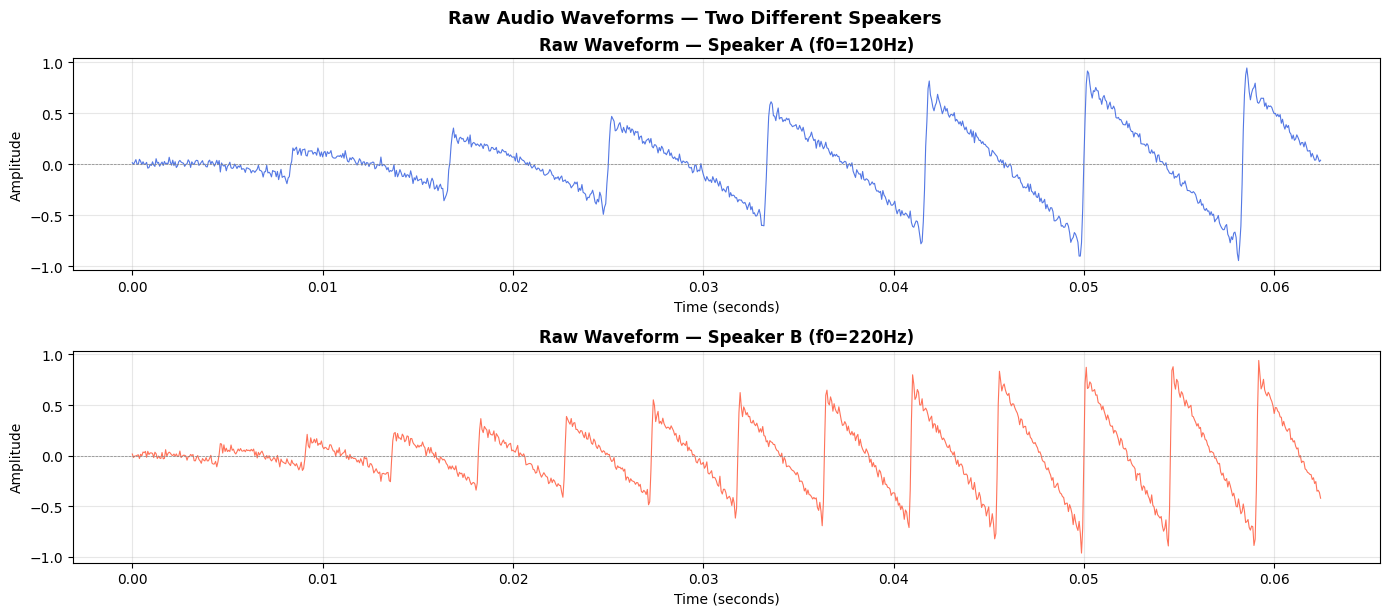

Speaker A: 48000 samples = 3.0 seconds
Speaker B: 48000 samples = 3.0 seconds

💡 These look similar! The waveform doesn't clearly show speaker identity.
   That's why we use spectrograms — they reveal WHAT frequencies are present.


In [6]:
# ============================================================
# CELL 3: Create synthetic audio for demonstration
# WHY: We don't want to depend on downloading files.
#      Real speech is a mix of harmonics (periodic) + noise (fricatives).
#      We'll simulate this with sine waves + noise. In practice, load .wav files.
# ============================================================

def generate_synthetic_speech(duration=2.0, sample_rate=16000, f0=120, formants=[700, 1200, 2600]):
    """
    Generate a synthetic vowel-like sound.
    
    In real speech:
    - f0 (fundamental frequency) = pitch. Male ~120Hz, Female ~220Hz
    - Formants = resonance frequencies of the vocal tract that shape vowels
    - A vowel like 'ah' has F1≈700Hz, F2≈1200Hz, F3≈2600Hz
    """
    t = np.linspace(0, duration, int(sample_rate * duration))
    
    # Glottal source: a harmonic series (fundamental + overtones)
    # This simulates the vibrating vocal cords
    source = np.zeros_like(t)
    for harmonic in range(1, 20):  # First 20 harmonics
        source += (1.0 / harmonic) * np.sin(2 * np.pi * f0 * harmonic * t)
    
    # Apply amplitude envelope (natural speech has rise/fall)
    envelope = np.ones_like(t)
    fade = int(0.05 * sample_rate)  # 50ms fade
    envelope[:fade] = np.linspace(0, 1, fade)
    envelope[-fade:] = np.linspace(1, 0, fade)
    
    signal = source * envelope
    
    # Add slight noise (breath, fricative components)
    signal += 0.05 * np.random.randn(len(t))
    
    # Normalize to [-1, 1]
    signal = signal / np.max(np.abs(signal))
    
    return signal.astype(np.float32)

# Generate two "speakers" with different f0 (different pitch = different speaker identity)
speaker_A = generate_synthetic_speech(duration=3.0, f0=120, formants=[700, 1200, 2600])  # Low pitch (male-ish)
speaker_B = generate_synthetic_speech(duration=3.0, f0=220, formants=[800, 1400, 2800])  # High pitch (female-ish)

# Visualize the raw waveform
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for ax, signal, label, color in zip(axes, [speaker_A, speaker_B], ['Speaker A (f0=120Hz)', 'Speaker B (f0=220Hz)'], ['royalblue', 'tomato']):
    time = np.arange(len(signal)) / SAMPLE_RATE
    ax.plot(time[:1000], signal[:1000], color=color, linewidth=0.8, alpha=0.9)  # Show first 62ms
    ax.set_title(f'Raw Waveform — {label}', fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Amplitude')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Raw Audio Waveforms — Two Different Speakers', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f"Speaker A: {len(speaker_A)} samples = {len(speaker_A)/SAMPLE_RATE:.1f} seconds")
print(f"Speaker B: {len(speaker_B)} samples = {len(speaker_B)/SAMPLE_RATE:.1f} seconds")
print("\n💡 These look similar! The waveform doesn't clearly show speaker identity.")
print("   That's why we use spectrograms — they reveal WHAT frequencies are present.")

<a id='3'></a>
## 📊 Section 3 — Feature Engineering: From Waveform to Spectrogram

### The Short-Time Fourier Transform (STFT)

The raw waveform is hard to work with because:
1. It's too long (16,000 samples/second)
2. It doesn't show what FREQUENCIES are present
3. Neural nets need structured input

The **STFT** solution:
1. Slide a window of `N_FFT=1024` samples across the signal
2. Move by `HOP_LENGTH=256` samples each step
3. Apply FFT to each window → get frequency content at that time
4. Stack all windows → get a **Time × Frequency** matrix = **Spectrogram**

**Window function:** We multiply each chunk by a Hann window before FFT. Why? The FFT assumes the signal is periodic. If we just cut a chunk, the sudden start/end creates fake high-frequency artifacts (called **spectral leakage**). The Hann window tapers the edges to zero, eliminating this.

### From Linear to Mel Scale

The human ear doesn't perceive frequencies linearly. Going from 100Hz → 200Hz sounds like a bigger jump than 1000Hz → 1100Hz, even though both are +100Hz. The **mel scale** mimics human perception:

```
mel = 2595 × log₁₀(1 + f/700)
```

We apply a **mel filterbank** — a set of triangular filters spread across the mel scale — to compress our spectrogram from `N_FFT//2+1 = 513` frequency bins down to `N_MELS = 80` bins. This is perceptually meaningful and computationally cheap.

### Log Mel Spectrogram

We take the log of the mel spectrogram: `log_mel = log(mel + 1e-6)`

Why?
- Human hearing is logarithmic (decibel scale)
- Compresses the dynamic range (speech can span 60dB — log makes this manageable)
- Neural nets train better with normalized, smaller-range inputs

STFT output shape (freq_bins × time_frames): (513, 188)
Frequency bins: 513 (= N_FFT//2 + 1 = 1024//2 + 1)
Time frames: 188
Each frame covers: 64.0ms, steps by: 16.0ms

Frequency resolution: 15.6 Hz per bin
(We can distinguish frequencies 15.6Hz apart)


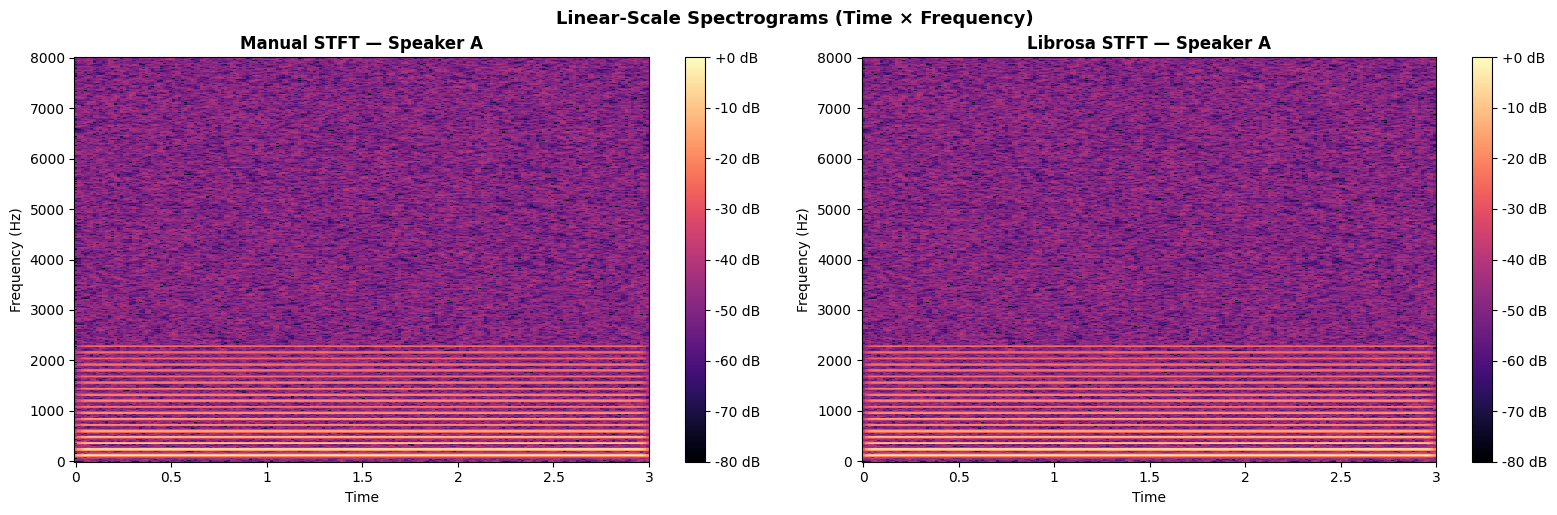


💡 The bright horizontal lines are HARMONICS — multiples of f0=120Hz
   You can see 120Hz, 240Hz, 360Hz, 480Hz... They reveal the speaker's pitch!


In [7]:
# ============================================================
# CELL 4: Computing the STFT — step by step
# We implement it manually FIRST, then use librosa for efficiency
# This is crucial for interviews: explain what's happening inside
# ============================================================

def manual_stft(signal, n_fft=1024, hop_length=256, window='hann'):
    """
    Manually compute STFT. Returns magnitude spectrogram.
    This is what librosa.stft does internally.
    """
    # Create the window function
    # Hann window: w[n] = 0.5 * (1 - cos(2π*n/(N-1)))
    win = np.hanning(n_fft)  # Hann window, shape (n_fft,)
    
    # Pad signal so first/last frames are centered
    pad_length = n_fft // 2
    signal_padded = np.pad(signal, pad_length, mode='reflect')
    
    # How many frames will we have?
    n_frames = 1 + (len(signal)) // hop_length
    
    # Output matrix: (n_fft//2 + 1) frequency bins × n_frames time steps
    n_freqs = n_fft // 2 + 1
    spectrogram = np.zeros((n_freqs, n_frames), dtype=complex)
    
    for frame_idx in range(n_frames):
        # Extract the window
        start = frame_idx * hop_length
        end = start + n_fft
        if end > len(signal_padded):
            break
        chunk = signal_padded[start:end]
        
        # Apply window (reduces spectral leakage)
        windowed = chunk * win
        
        # Apply FFT — converts time domain to frequency domain
        # rfft: FFT for real signals (returns only positive frequencies)
        spectrum = np.fft.rfft(windowed)
        spectrogram[:, frame_idx] = spectrum
    
    return spectrogram

# Compute our manual STFT
stft_manual = manual_stft(speaker_A, n_fft=N_FFT, hop_length=HOP_LENGTH)
magnitude_manual = np.abs(stft_manual)  # |complex| = magnitude

# Also compute using librosa (should match)
stft_librosa = librosa.stft(speaker_A, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
magnitude_librosa = np.abs(stft_librosa)

print(f"STFT output shape (freq_bins × time_frames): {magnitude_manual.shape}")
print(f"Frequency bins: {magnitude_manual.shape[0]} (= N_FFT//2 + 1 = {N_FFT}//2 + 1)")
print(f"Time frames: {magnitude_manual.shape[1]}")
print(f"Each frame covers: {N_FFT/SAMPLE_RATE*1000:.1f}ms, steps by: {HOP_LENGTH/SAMPLE_RATE*1000:.1f}ms")
print(f"\nFrequency resolution: {SAMPLE_RATE/N_FFT:.1f} Hz per bin")
print(f"(We can distinguish frequencies {SAMPLE_RATE/N_FFT:.1f}Hz apart)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, mag, title in zip(axes, [magnitude_manual, magnitude_librosa], ['Manual STFT', 'Librosa STFT']):
    img = librosa.display.specshow(
        librosa.amplitude_to_db(mag, ref=np.max),
        sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='hz', ax=ax, cmap='magma'
    )
    ax.set_title(f'{title} — Speaker A', fontweight='bold')
    ax.set_ylabel('Frequency (Hz)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.suptitle('Linear-Scale Spectrograms (Time × Frequency)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print("\n💡 The bright horizontal lines are HARMONICS — multiples of f0=120Hz")
print("   You can see 120Hz, 240Hz, 360Hz, 480Hz... They reveal the speaker's pitch!")

Mel spectrogram shape: (80, 188)  = (n_mels=80, time_frames)
This is our 'image' that neural nets will process!

For reference — original STFT had 513 frequency bins
Mel spectrogram has 80 bins — 84% dimension reduction!


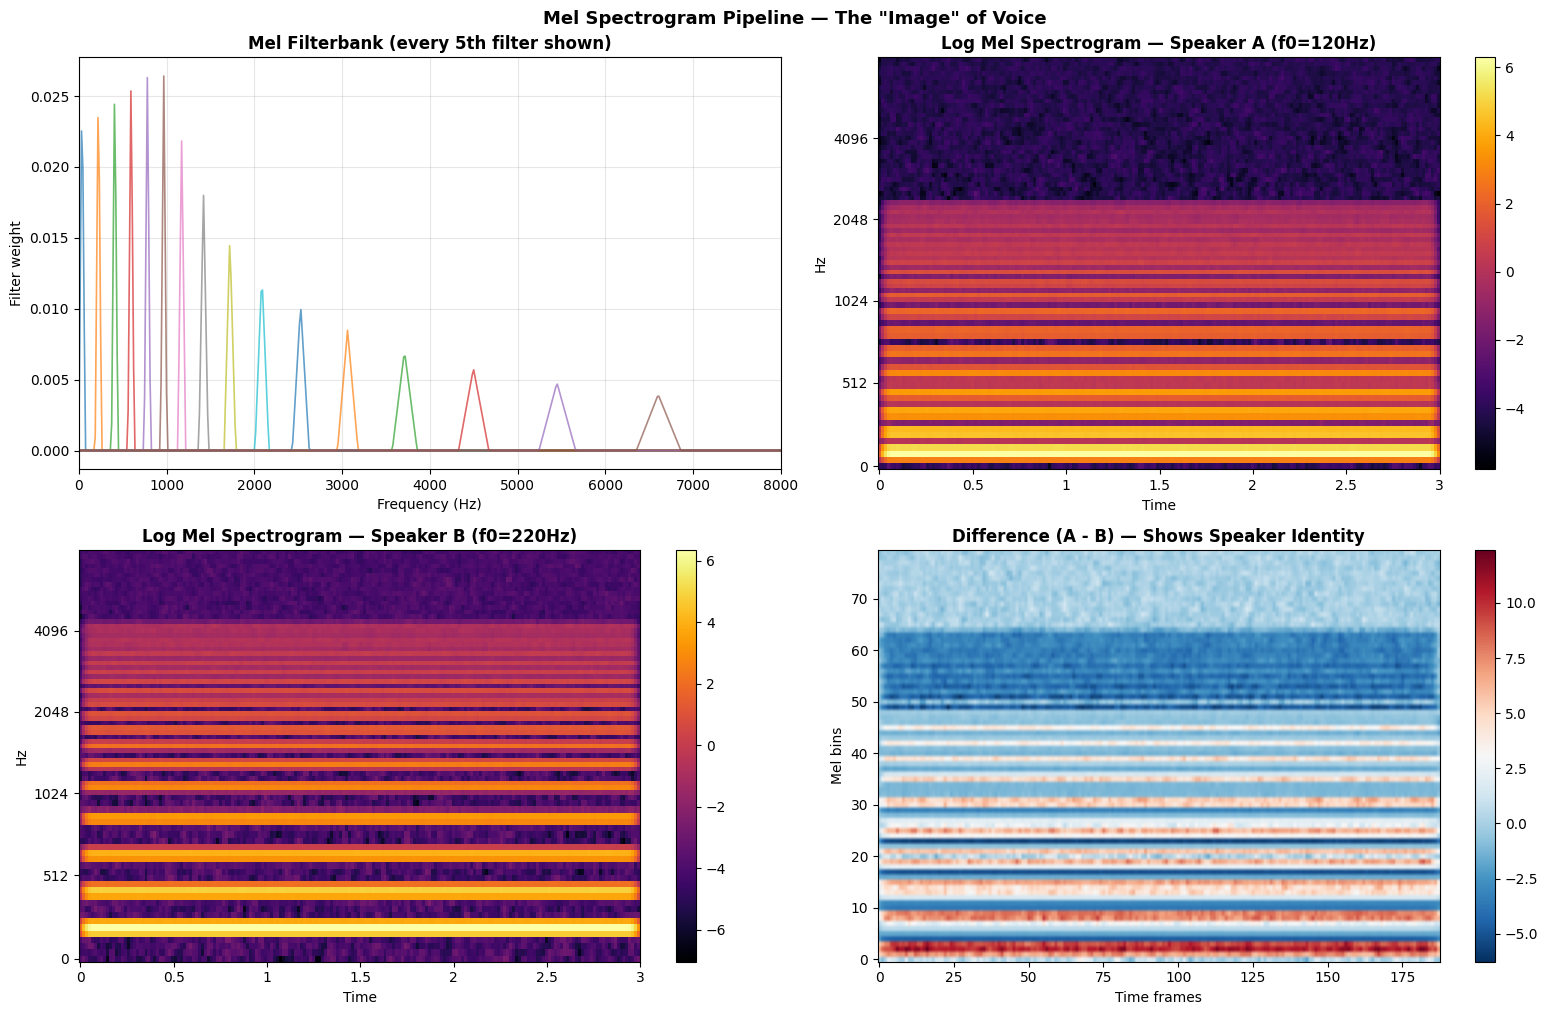

In [8]:
# ============================================================
# CELL 5: Computing the Mel Spectrogram
# This is the bread-and-butter feature for ALL modern TTS systems
# ============================================================

def compute_mel_spectrogram(signal, sample_rate=16000, n_fft=1024, 
                             hop_length=256, n_mels=80, fmin=0, fmax=8000):
    """
    Full pipeline: waveform → log mel spectrogram
    
    Steps:
    1. STFT: time domain → complex spectrogram
    2. Power spectrum: |STFT|² 
    3. Mel filterbank: compress 513 bins → 80 perceptual bins
    4. Log: compress dynamic range
    """
    # Step 1: STFT → magnitude
    stft = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, win_length=n_fft)
    magnitude = np.abs(stft)  # Shape: (n_fft//2+1, T)
    
    # Step 2: Power spectrum (squaring emphasizes louder components)
    power = magnitude ** 2  # Shape: (n_fft//2+1, T)
    
    # Step 3: Apply mel filterbank
    # This creates a matrix M of shape (n_mels, n_fft//2+1)
    # where each row is one triangular filter
    mel_filters = librosa.filters.mel(
        sr=sample_rate, n_fft=n_fft, n_mels=n_mels, fmin=fmin, fmax=fmax
    )  # Shape: (n_mels, n_fft//2+1)
    
    mel_spec = np.dot(mel_filters, power)  # Shape: (n_mels, T)
    
    # Step 4: Log compression
    # Add small constant to avoid log(0)
    log_mel = np.log(mel_spec + 1e-6)  # Shape: (n_mels, T)
    
    return log_mel, mel_filters, magnitude


# Compute for both speakers
mel_A, mel_filters, mag_A = compute_mel_spectrogram(speaker_A)
mel_B, _, mag_B = compute_mel_spectrogram(speaker_B)

print(f"Mel spectrogram shape: {mel_A.shape}  = (n_mels={N_MELS}, time_frames)")
print(f"This is our 'image' that neural nets will process!")
print(f"\nFor reference — original STFT had {N_FFT//2+1} frequency bins")
print(f"Mel spectrogram has {N_MELS} bins — {(N_FFT//2+1 - N_MELS)/(N_FFT//2+1)*100:.0f}% dimension reduction!")

# Visualize the mel filterbank
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mel filterbank visualization
ax = axes[0, 0]
freq_axis = np.linspace(0, SAMPLE_RATE//2, N_FFT//2+1)
for i in range(0, N_MELS, 5):  # Show every 5th filter
    ax.plot(freq_axis, mel_filters[i], alpha=0.7, linewidth=1.2)
ax.set_title('Mel Filterbank (every 5th filter shown)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Filter weight')
ax.set_xlim(0, 8000)
ax.grid(True, alpha=0.3)
ax.annotate('Filters are WIDER\nat high frequencies\n(mel scale)', 
             xy=(4000, 0.04), fontsize=9, color='gray',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# 2. Speaker A mel spectrogram
ax = axes[0, 1]
img = librosa.display.specshow(mel_A, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                 x_axis='time', y_axis='mel', ax=ax, cmap='inferno')
ax.set_title('Log Mel Spectrogram — Speaker A (f0=120Hz)', fontweight='bold')
plt.colorbar(img, ax=ax)

# 3. Speaker B mel spectrogram
ax = axes[1, 0]
img = librosa.display.specshow(mel_B, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                 x_axis='time', y_axis='mel', ax=ax, cmap='inferno')
ax.set_title('Log Mel Spectrogram — Speaker B (f0=220Hz)', fontweight='bold')
plt.colorbar(img, ax=ax)

# 4. Difference between speakers
ax = axes[1, 1]
min_t = min(mel_A.shape[1], mel_B.shape[1])
diff = mel_A[:, :min_t] - mel_B[:, :min_t]
img = ax.imshow(diff, aspect='auto', origin='lower', cmap='RdBu_r')
ax.set_title('Difference (A - B) — Shows Speaker Identity', fontweight='bold')
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel bins')
plt.colorbar(img, ax=ax)

plt.tight_layout()
plt.suptitle('Mel Spectrogram Pipeline — The "Image" of Voice', y=1.01, fontsize=13, fontweight='bold')
plt.show()

<a id='4'></a>
## 🎛️ Section 4 — MFCCs: The "Images" of Audio

### What are MFCCs?

**Mel-Frequency Cepstral Coefficients** are the most widely used audio features in speech processing (ASR, speaker verification, emotion detection).

**The pipeline:**
```
Waveform → Mel Spectrogram → log() → DCT → MFCCs
```

**Why the DCT (Discrete Cosine Transform)?**
- The mel spectrogram has correlated adjacent frequency bins (neighboring mels are similar)
- DCT decorrelates these → each coefficient carries unique information
- It's like PCA: the first few DCT coefficients capture most of the variance
- We typically keep only the first 13-40 coefficients (the rest is mostly noise)

**What do the coefficients represent?**
- **MFCC-0:** Overall energy (loudness)
- **MFCC-1:** Broad spectral tilt (more energy in low vs high frequencies)
- **MFCC-2..12:** Progressively finer spectral shape details
- **Delta MFCCs:** Rate of change of each MFCC (captures dynamics)
- **Delta-Delta MFCCs:** Acceleration (captures rhythm patterns)

**Interview answer:** "MFCCs are compact, decorrelated representations of the spectral envelope of audio. They capture the slowly-varying shape of the spectrum that characterizes a speaker's vocal tract, while being robust to pitch variation — different speakers saying the same word have similar MFCCs despite different pitches."

### Cepstrum — The Clever Math Trick

The word "cepstrum" is an anagram of "spectrum" 😄. The key insight:

```
Speech = Vocal tract filter × Glottal source
log(Speech) = log(Filter) + log(Source)
DCT(log(Speech)) = DCT(log(Filter)) + DCT(log(Source))
```

The glottal source (pitch harmonics) has rapid variations → high DCT coefficients.
The vocal tract filter (speaker identity, vowel shape) varies slowly → low DCT coefficients.

By keeping only the low DCT coefficients, **we separate speaker identity (MFCCs) from pitch (fundamental frequency)**. This is the cepstral "liftering" trick.

MFCCs shape: (40, 188)  = (n_mfcc=40, time_frames)
Delta MFCCs shape: (40, 188)
Full feature vector (MFCC + Δ + ΔΔ): (120, 188)
Each time frame → 120-dim vector


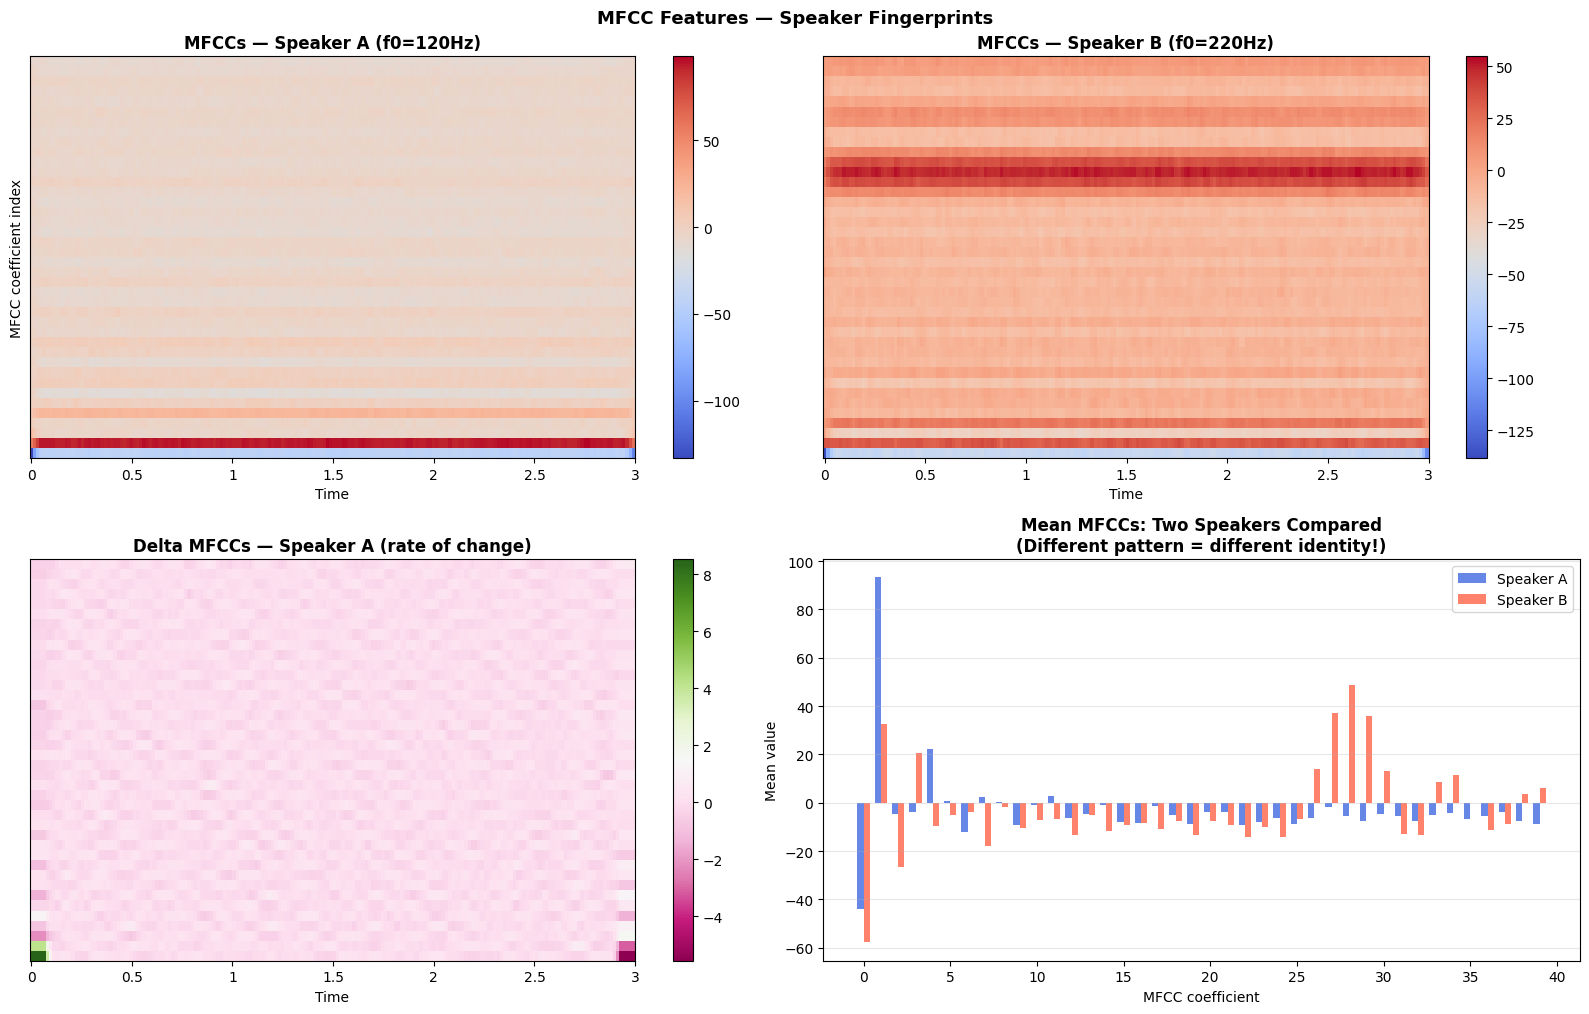


💡 Key insight: Speakers A and B have DIFFERENT MFCC patterns!
   MFCCs capture the SHAPE of the vocal tract (speaker identity), not pitch.
   This is why MFCCs work for speaker verification despite different pitches.


In [9]:
# ============================================================
# CELL 6: Computing MFCCs — Manual + Librosa
# ============================================================

from scipy.fft import dct

def compute_mfccs_manual(signal, sample_rate=16000, n_fft=1024, hop_length=256, 
                          n_mels=80, n_mfcc=40):
    """
    Manual MFCC computation:
    signal → STFT → power spectrum → mel filterbank → log → DCT → MFCCs
    """
    # Steps 1-4: Compute log mel spectrogram
    log_mel, _, _ = compute_mel_spectrogram(signal, sample_rate, n_fft, hop_length, n_mels)
    
    # Step 5: Apply DCT along the frequency axis (axis=0)
    # DCT-II is the standard choice
    mfccs = dct(log_mel, type=2, axis=0, norm='ortho')  # Shape: (n_mels, T)
    
    # Step 6: Keep only first n_mfcc coefficients
    mfccs = mfccs[:n_mfcc, :]  # Shape: (n_mfcc, T)
    
    return mfccs


def compute_delta(features, width=9):
    """
    Compute delta (first derivative) of features over time.
    Delta captures HOW FAST features are changing — encodes speech dynamics.
    Uses a polynomial regression over a window of 'width' frames.
    """
    # Simple finite difference approximation
    delta = np.zeros_like(features)
    half = width // 2
    for t in range(features.shape[1]):
        t_lo = max(0, t - half)
        t_hi = min(features.shape[1] - 1, t + half)
        slope_num = np.sum([
            i * features[:, t + i]
            for i in range(-min(half, t), min(half, features.shape[1]-1-t)+1)
            if 0 <= t+i < features.shape[1]
        ], axis=0)
        slope_den = max(1, sum(i**2 for i in range(-min(half, t), min(half, features.shape[1]-1-t)+1)))
        delta[:, t] = slope_num / slope_den
    return delta


# Compute MFCCs for both speakers
N_MFCC = 40
mfcc_A = compute_mfccs_manual(speaker_A, n_mfcc=N_MFCC)
mfcc_B = compute_mfccs_manual(speaker_B, n_mfcc=N_MFCC)

# Also compute using librosa to verify
mfcc_A_librosa = librosa.feature.mfcc(y=speaker_A, sr=SAMPLE_RATE, n_mfcc=N_MFCC, 
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)

# Compute deltas
delta_A = librosa.feature.delta(mfcc_A_librosa)
delta2_A = librosa.feature.delta(mfcc_A_librosa, order=2)

# Stack: [MFCCs, Δ, ΔΔ] → 120-dim feature vector per frame
full_features_A = np.vstack([mfcc_A_librosa, delta_A, delta2_A])

print(f"MFCCs shape: {mfcc_A.shape}  = (n_mfcc={N_MFCC}, time_frames)")
print(f"Delta MFCCs shape: {delta_A.shape}")
print(f"Full feature vector (MFCC + Δ + ΔΔ): {full_features_A.shape}")
print(f"Each time frame → {full_features_A.shape[0]}-dim vector")

# Visualize MFCCs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Speaker A MFCCs
ax = axes[0, 0]
img = librosa.display.specshow(mfcc_A_librosa, x_axis='time', ax=ax, cmap='coolwarm',
                                 sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
ax.set_title('MFCCs — Speaker A (f0=120Hz)', fontweight='bold')
ax.set_ylabel('MFCC coefficient index')
plt.colorbar(img, ax=ax)

# Speaker B MFCCs
ax = axes[0, 1]
mfcc_B_librosa = librosa.feature.mfcc(y=speaker_B, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
img = librosa.display.specshow(mfcc_B_librosa, x_axis='time', ax=ax, cmap='coolwarm',
                                 sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
ax.set_title('MFCCs — Speaker B (f0=220Hz)', fontweight='bold')
plt.colorbar(img, ax=ax)

# Delta MFCCs
ax = axes[1, 0]
img = librosa.display.specshow(delta_A, x_axis='time', ax=ax, cmap='PiYG',
                                 sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
ax.set_title('Delta MFCCs — Speaker A (rate of change)', fontweight='bold')
plt.colorbar(img, ax=ax)

# Mean MFCC comparison between speakers
ax = axes[1, 1]
mean_A = np.mean(mfcc_A_librosa, axis=1)
mean_B = np.mean(mfcc_B_librosa, axis=1)
x = np.arange(N_MFCC)
width = 0.35
ax.bar(x - width/2, mean_A, width, label='Speaker A', color='royalblue', alpha=0.8)
ax.bar(x + width/2, mean_B, width, label='Speaker B', color='tomato', alpha=0.8)
ax.set_title('Mean MFCCs: Two Speakers Compared\n(Different pattern = different identity!)', fontweight='bold')
ax.set_xlabel('MFCC coefficient')
ax.set_ylabel('Mean value')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('MFCC Features — Speaker Fingerprints', y=1.01, fontsize=13, fontweight='bold')
plt.show()

print("\n💡 Key insight: Speakers A and B have DIFFERENT MFCC patterns!")
print("   MFCCs capture the SHAPE of the vocal tract (speaker identity), not pitch.")
print("   This is why MFCCs work for speaker verification despite different pitches.")

<a id='5'></a>
## 👤 Section 5 — Speaker Embeddings: Capturing Voice Identity

### The Core Idea

A **speaker embedding** is a fixed-size vector (e.g., 256-dim) that represents a speaker's unique voice characteristics. Think of it like a **face embedding** in face recognition — but for voice.

**The goal:** Given any audio clip of Speaker X, the encoder should produce a vector `e_X` such that:
- Two clips of Speaker X → similar vectors (`e_X1 ≈ e_X2`)
- Clips of different speakers → distant vectors (`e_X ≠ e_Y`)

### Architecture: The d-Vector / GE2E Encoder

The de facto standard is a **LSTM-based speaker encoder** trained with a **GE2E (Generalized End-to-End) loss** (Google's paper: "Generalized End-to-End Loss for Speaker Verification"):

```
Input: Variable-length audio → MFCCs → (T × 40) matrix
  ↓
LSTM (3 layers, hidden=768)
  ↓
Take last hidden state OR mean of all states
  ↓
Linear(768 → 256)
  ↓
L2 Normalize → unit sphere
  ↓
Speaker embedding e ∈ ℝ²⁵⁶, ||e||₂ = 1
```

### Why L2 Normalize?

We project all embeddings onto the unit hypersphere. Then:
- Cosine similarity = dot product (fast!)
- Embeddings can only differ in **direction**, not magnitude
- Clustering algorithms work better on normalized embeddings
- The GE2E loss uses cosine similarity directly

### Training Objective: Triplet Loss vs GE2E

**Triplet Loss (simpler, conceptually clear):**
```
Loss = max(0, d(anchor, positive) - d(anchor, negative) + margin)
```
Where: anchor = reference clip of speaker, positive = different clip of SAME speaker, negative = clip of DIFFERENT speaker.

We want `d(anchor, positive) < d(anchor, negative)` — same speaker should be closer.

**GE2E Loss (more powerful):** Uses a batch of speakers × utterances, computes a similarity matrix, and applies softmax. More stable and efficient.

For our from-scratch implementation, we'll use **Triplet Loss** as it's easier to understand and implement.

In [10]:
# ============================================================
# CELL 7: Speaker Encoder — LSTM-based d-vector
# ============================================================

class SpeakerEncoder(nn.Module):
    """
    LSTM-based speaker encoder that produces a fixed-size embedding
    from variable-length audio (represented as MFCCs).
    
    Architecture follows:
    Wan et al. (2018) "Generalized End-to-End Loss for Speaker Verification"
    
    Input: (batch, time_frames, n_mfcc) — MFCCs of audio clips
    Output: (batch, embedding_dim) — L2-normalized speaker embeddings
    """
    
    def __init__(self, input_dim=40, hidden_dim=256, num_layers=3, embedding_dim=128):
        """
        Args:
            input_dim: Number of MFCC features per frame (default: 40)
            hidden_dim: LSTM hidden state size. Bigger = more expressive but slower
            num_layers: LSTM depth. 3 is the sweet spot for speaker verification
            embedding_dim: Output embedding dimension. 128-256 is standard
        """
        super(SpeakerEncoder, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding_dim = embedding_dim
        
        # LSTM: processes sequence of MFCC frames
        # batch_first=True: input shape is (batch, seq, features)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0  # Dropout between LSTM layers
        )
        
        # Projection layer: hidden_dim → embedding_dim
        # Using linear without bias is common in metric learning
        self.projection = nn.Linear(hidden_dim, embedding_dim, bias=False)
        
        # Layer norm helps stabilize training
        self.ln = nn.LayerNorm(embedding_dim)
        
        # Initialize weights for better training stability
        self._init_weights()
        
    def _init_weights(self):
        """Xavier initialization for LSTM, ensures gradients don't vanish/explode at start"""
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)  # Orthogonal init helps LSTM stability
            elif 'bias' in name:
                param.data.fill_(0)
                # Set forget gate bias to 1 — helps with long-term memory
                n = param.size(0)
                param.data[(n//4):(n//2)].fill_(1.0)
    
    def forward(self, x, use_mean=True):
        """
        Args:
            x: MFCC features, shape (batch, time_frames, n_mfcc)
            use_mean: If True, average all LSTM outputs (more robust).
                      If False, use only last output (faster but less robust).
        Returns:
            embedding: L2-normalized speaker embedding, shape (batch, embedding_dim)
        """
        # LSTM forward pass
        # output: (batch, time, hidden_dim) — all timestep outputs
        # h_n:    (num_layers, batch, hidden_dim) — final hidden state
        output, (h_n, c_n) = self.lstm(x)
        
        if use_mean:
            # Mean pooling over time — more robust to varying clip lengths
            # "What is the speaker's average voice characteristic across the clip?"
            pooled = output.mean(dim=1)  # Shape: (batch, hidden_dim)
        else:
            # Take the last timestep output
            # Works well when audio clips are similar length
            pooled = output[:, -1, :]  # Shape: (batch, hidden_dim)
        
        # Project to embedding space
        embedding = self.projection(pooled)  # Shape: (batch, embedding_dim)
        
        # Layer normalization
        embedding = self.ln(embedding)
        
        # L2 normalization — project onto unit hypersphere
        # After this, ||embedding||₂ = 1 for all samples
        # Cosine similarity becomes equivalent to dot product
        embedding = F.normalize(embedding, p=2, dim=1)
        
        return embedding


# Instantiate the encoder
encoder = SpeakerEncoder(
    input_dim=N_MFCC,       # 40 MFCC features
    hidden_dim=256,          # LSTM hidden state
    num_layers=3,            # 3 LSTM layers
    embedding_dim=128        # Output embedding size
)

# Count parameters
total_params = sum(p.numel() for p in encoder.parameters())
trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print("Speaker Encoder Architecture:")
print(encoder)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Speaker Encoder Architecture:
SpeakerEncoder(
  (lstm): LSTM(40, 256, num_layers=3, batch_first=True, dropout=0.2)
  (projection): Linear(in_features=256, out_features=128, bias=False)
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)

Total parameters: 1,390,848
Trainable parameters: 1,390,848


In [11]:
# ============================================================
# CELL 8: Triplet Loss — Training the Speaker Encoder
# ============================================================

class TripletLoss(nn.Module):
    """
    Triplet Loss for metric learning.
    
    Intuition: Given:
    - Anchor (a): reference sample from speaker X
    - Positive (p): different sample from SAME speaker X  
    - Negative (n): sample from DIFFERENT speaker Y
    
    We want: d(a, p) < d(a, n) - margin
    i.e., same-speaker pairs are closer than cross-speaker pairs (by at least 'margin')
    
    Loss = max(0, d(a,p) - d(a,n) + margin)
    
    On the unit sphere (L2-normalized embeddings):
    - d(a,p) = 1 - cos(a,p)  (1 minus cosine similarity)
    - Using cosine distance instead of Euclidean is more stable
    """
    
    def __init__(self, margin=0.3):
        """
        margin: The minimum gap we enforce between positive and negative distances.
                Too small: easy to satisfy, model learns nothing.
                Too large: impossible to satisfy, gradients explode.
                0.3 is a good starting point for cosine distance.
        """
        super().__init__()
        self.margin = margin
    
    def forward(self, anchor, positive, negative):
        """
        Args:
            anchor: (batch, embedding_dim) — L2-normalized
            positive: (batch, embedding_dim) — L2-normalized
            negative: (batch, embedding_dim) — L2-normalized
        Returns:
            loss: scalar
        """
        # Cosine similarity: a·b (since vectors are L2-normalized, ||a||=||b||=1)
        # Range: [-1, 1]. 1 = identical direction, -1 = opposite
        cos_pos = (anchor * positive).sum(dim=1)  # (batch,)
        cos_neg = (anchor * negative).sum(dim=1)  # (batch,)
        
        # Convert to distances: d = 1 - cos_sim
        # Range: [0, 2]. 0 = same direction, 2 = opposite
        d_pos = 1 - cos_pos  # Distance to positive (want small)
        d_neg = 1 - cos_neg  # Distance to negative (want large)
        
        # Triplet loss: only penalize when positive is NOT closer than negative by margin
        loss = F.relu(d_pos - d_neg + self.margin)  # max(0, d_pos - d_neg + margin)
        
        # Mean over batch
        return loss.mean(), d_pos.mean().item(), d_neg.mean().item()


class SpeakerDataset:
    """
    Simulated dataset of speakers.
    In reality, you'd use LJSpeech, VCTK, LibriSpeech, etc.
    
    For demonstration: we generate multiple clips per speaker
    by adding slight variations (amplitude, noise) to our base signals.
    """
    
    def __init__(self, n_speakers=10, clips_per_speaker=20, n_mfcc=40):
        self.n_speakers = n_speakers
        self.clips_per_speaker = clips_per_speaker
        self.n_mfcc = n_mfcc
        
        # Generate speakers with different f0 (fundamental frequency)
        # f0 range: 80Hz (deep male) to 280Hz (high female)
        self.speaker_f0s = np.linspace(80, 280, n_speakers)
        
        # Pre-compute all clip embeddings as raw MFCCs
        self.data = self._generate_data()
    
    def _generate_data(self):
        """Generate MFCC features for all speakers × clips"""
        data = {}  # speaker_id → list of MFCC tensors
        
        for spk_id, f0 in enumerate(self.speaker_f0s):
            clips = []
            for clip_idx in range(self.clips_per_speaker):
                # Add slight random variation to simulate different utterances
                f0_jitter = f0 + np.random.uniform(-5, 5)  # ±5Hz pitch jitter
                duration = np.random.uniform(1.5, 3.0)      # Variable length clips
                
                signal = generate_synthetic_speech(
                    duration=duration, f0=f0_jitter, sample_rate=SAMPLE_RATE
                )
                
                # Compute MFCCs
                mfccs = librosa.feature.mfcc(
                    y=signal, sr=SAMPLE_RATE, n_mfcc=self.n_mfcc,
                    n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
                ).T  # Transpose to (time, n_mfcc)
                
                clips.append(mfccs)
            
            data[spk_id] = clips
        
        return data
    
    def get_triplet_batch(self, batch_size=16):
        """
        Sample a batch of (anchor, positive, negative) triplets.
        Returns fixed-length sequences by truncating/padding.
        """
        fixed_len = 50  # Fixed number of frames per clip
        
        anchors, positives, negatives = [], [], []
        
        for _ in range(batch_size):
            # Pick anchor speaker
            anc_spk = np.random.randint(self.n_speakers)
            
            # Pick negative speaker (different from anchor)
            neg_spk = np.random.randint(self.n_speakers)
            while neg_spk == anc_spk:
                neg_spk = np.random.randint(self.n_speakers)
            
            # Sample anchor clip
            anc_idx = np.random.randint(self.clips_per_speaker)
            # Sample positive clip (different clip, same speaker)
            pos_idx = np.random.randint(self.clips_per_speaker)
            while pos_idx == anc_idx:
                pos_idx = np.random.randint(self.clips_per_speaker)
            # Sample negative clip
            neg_idx = np.random.randint(self.clips_per_speaker)
            
            def pad_or_truncate(mfcc, target_len):
                if len(mfcc) >= target_len:
                    return mfcc[:target_len]
                else:
                    pad = np.zeros((target_len - len(mfcc), mfcc.shape[1]))
                    return np.vstack([mfcc, pad])
            
            anchors.append(pad_or_truncate(self.data[anc_spk][anc_idx], fixed_len))
            positives.append(pad_or_truncate(self.data[anc_spk][pos_idx], fixed_len))
            negatives.append(pad_or_truncate(self.data[neg_spk][neg_idx], fixed_len))
        
        # Convert to tensors
        to_tensor = lambda x: torch.FloatTensor(np.array(x))
        return to_tensor(anchors), to_tensor(positives), to_tensor(negatives)


# Create dataset and test
dataset = SpeakerDataset(n_speakers=10, clips_per_speaker=20, n_mfcc=N_MFCC)
a, p, n = dataset.get_triplet_batch(batch_size=8)

print(f"Triplet batch shapes:")
print(f"  Anchor:   {a.shape} = (batch, time_frames, n_mfcc)")
print(f"  Positive: {p.shape}")
print(f"  Negative: {n.shape}")

# Test encoder forward pass
with torch.no_grad():
    emb_a = encoder(a)
    emb_p = encoder(p)
    emb_n = encoder(n)

print(f"\nEmbedding shapes: {emb_a.shape} = (batch, embedding_dim)")
print(f"L2 norms (should be ~1.0): {torch.norm(emb_a, dim=1).mean():.4f}")

Triplet batch shapes:
  Anchor:   torch.Size([8, 50, 40]) = (batch, time_frames, n_mfcc)
  Positive: torch.Size([8, 50, 40])
  Negative: torch.Size([8, 50, 40])

Embedding shapes: torch.Size([8, 128]) = (batch, embedding_dim)
L2 norms (should be ~1.0): 1.0000


Training Speaker Encoder with Triplet Loss...
Watch: d_pos should DECREASE, d_neg should INCREASE (or stay high)
--------------------------------------------------------------------------------
Epoch  10/50 | Loss: 0.0000 | d_pos: 0.0109 | d_neg: 1.0059 | Separation: 0.9950 | LR: 1.00e-03
Epoch  20/50 | Loss: 0.0000 | d_pos: 0.0114 | d_neg: 1.0082 | Separation: 0.9968 | LR: 5.00e-04
Epoch  30/50 | Loss: 0.0000 | d_pos: 0.0042 | d_neg: 1.0056 | Separation: 1.0014 | LR: 2.50e-04
Epoch  40/50 | Loss: 0.0000 | d_pos: 0.0047 | d_neg: 0.9811 | Separation: 0.9764 | LR: 1.25e-04
Epoch  50/50 | Loss: 0.0000 | d_pos: 0.0052 | d_neg: 1.0608 | Separation: 1.0557 | LR: 6.25e-05


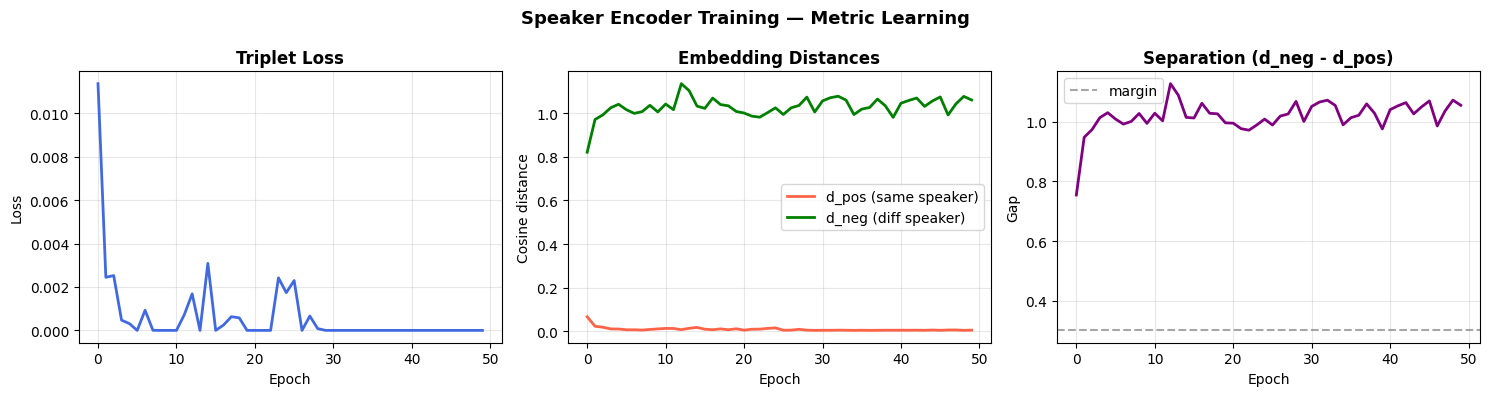

In [12]:
# ============================================================
# CELL 9: Training the Speaker Encoder
# ============================================================

def train_speaker_encoder(encoder, dataset, n_epochs=50, batch_size=16, lr=1e-3):
    """
    Training loop for the speaker encoder with triplet loss.
    
    We track:
    - Total loss (should decrease)
    - d_pos: average distance between same-speaker pairs (should decrease)
    - d_neg: average distance between different-speaker pairs (should increase)
    - Separation: d_neg - d_pos (should increase — wider margin = better)
    """
    
    triplet_loss = TripletLoss(margin=0.3)
    
    # Adam optimizer with learning rate scheduling
    # Adam = adaptive gradients. Good default for most problems.
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr, weight_decay=1e-4)
    
    # Reduce LR when loss plateaus (patience=10 epochs)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, verbose=False
    )
    
    history = {'loss': [], 'd_pos': [], 'd_neg': [], 'separation': []}
    
    for epoch in range(n_epochs):
        encoder.train()
        epoch_loss = 0
        epoch_dpos = 0
        epoch_dneg = 0
        n_batches = 10  # Batches per epoch
        
        for _ in range(n_batches):
            # Sample a batch of triplets
            anchor_batch, pos_batch, neg_batch = dataset.get_triplet_batch(batch_size)
            
            # Zero gradients — always do this at the start of each backward pass
            optimizer.zero_grad()
            
            # Forward pass through encoder
            emb_anchor = encoder(anchor_batch)
            emb_pos = encoder(pos_batch)
            emb_neg = encoder(neg_batch)
            
            # Compute triplet loss
            loss, d_pos, d_neg = triplet_loss(emb_anchor, emb_pos, emb_neg)
            
            # Backward pass — compute gradients
            loss.backward()
            
            # Gradient clipping — prevents exploding gradients in LSTMs
            # Without this, LSTMs can have gradients that blow up during training
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
            
            # Update weights
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_dpos += d_pos
            epoch_dneg += d_neg
        
        # Average over batches
        avg_loss = epoch_loss / n_batches
        avg_dpos = epoch_dpos / n_batches
        avg_dneg = epoch_dneg / n_batches
        separation = avg_dneg - avg_dpos
        
        scheduler.step(avg_loss)
        
        history['loss'].append(avg_loss)
        history['d_pos'].append(avg_dpos)
        history['d_neg'].append(avg_dneg)
        history['separation'].append(separation)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"d_pos: {avg_dpos:.4f} | "
                  f"d_neg: {avg_dneg:.4f} | "
                  f"Separation: {separation:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    return history


print("Training Speaker Encoder with Triplet Loss...")
print("Watch: d_pos should DECREASE, d_neg should INCREASE (or stay high)")
print("-" * 80)
history = train_speaker_encoder(encoder, dataset, n_epochs=50, batch_size=16, lr=1e-3)

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'], 'royalblue', linewidth=2)
axes[0].set_title('Triplet Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['d_pos'], 'tomato', linewidth=2, label='d_pos (same speaker)')
axes[1].plot(history['d_neg'], 'green', linewidth=2, label='d_neg (diff speaker)')
axes[1].set_title('Embedding Distances', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cosine distance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['separation'], 'purple', linewidth=2)
axes[2].set_title('Separation (d_neg - d_pos)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Gap')
axes[2].axhline(0.3, color='gray', linestyle='--', alpha=0.7, label='margin')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Speaker Encoder Training — Metric Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Total embeddings: (200, 128)
Reducing to 2D with t-SNE...


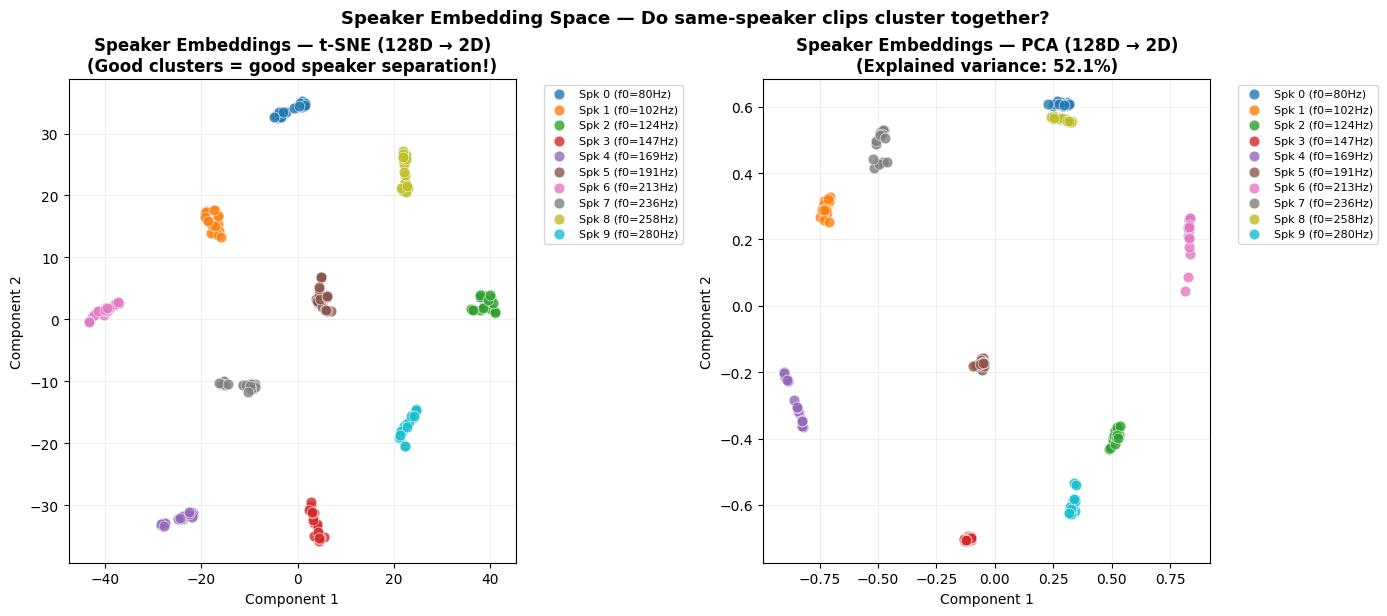


💡 Each color = one speaker. Tight clusters = encoder learned speaker identity!
   In practice, train on 1000s of speakers for hours on a GPU for production quality.


In [14]:
# ============================================================
# CELL 10: Visualizing Speaker Embeddings with t-SNE
# t-SNE reduces 128-dim embeddings to 2D for visualization
# Good clusters = good speaker separation = good encoder!
# ============================================================

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Generate embeddings for all speakers and clips
encoder.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for spk_id in range(dataset.n_speakers):
        for clip in dataset.data[spk_id]:
            # Prepare: pad/truncate to 50 frames
            if len(clip) >= 50:
                clip_fixed = clip[:50]
            else:
                pad = np.zeros((50 - len(clip), clip.shape[1]))
                clip_fixed = np.vstack([clip, pad])
            
            # Add batch dimension, forward pass
            x = torch.FloatTensor(clip_fixed).unsqueeze(0)  # (1, 50, 40)
            emb = encoder(x).squeeze(0).numpy()  # (128,)
            all_embeddings.append(emb)
            all_labels.append(spk_id)

all_embeddings = np.array(all_embeddings)  # (n_speakers * clips_per_speaker, 128)
all_labels = np.array(all_labels)

print(f"Total embeddings: {all_embeddings.shape}")
print(f"Reducing to 2D with t-SNE...")

# t-SNE for visualization
# perplexity ≈ neighborhood size. 5-50 is typical.
tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, dataset.n_speakers))

for ax, title in zip(axes, ['t-SNE (128D → 2D)', 'PCA (128D → 2D)']):
    if 'PCA' in title:
        pca = PCA(n_components=2)
        pts = pca.fit_transform(all_embeddings)
        ax.set_title(f'Speaker Embeddings — {title}\n(Explained variance: {pca.explained_variance_ratio_.sum():.1%})', 
                     fontweight='bold')
    else:
        pts = embeddings_2d
        ax.set_title(f'Speaker Embeddings — {title}\n(Good clusters = good speaker separation!)', 
                     fontweight='bold')
    
    for spk_id in range(dataset.n_speakers):
        mask = all_labels == spk_id
        f0 = dataset.speaker_f0s[spk_id]
        ax.scatter(pts[mask, 0], pts[mask, 1], 
                   color=colors[spk_id], alpha=0.8, s=60,
                   label=f'Spk {spk_id} (f0={f0:.0f}Hz)',
                   edgecolors='white', linewidths=0.5)
    
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.suptitle('Speaker Embedding Space — Do same-speaker clips cluster together?', 
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print("\n💡 Each color = one speaker. Tight clusters = encoder learned speaker identity!")
print("   In practice, train on 1000s of speakers for hours on a GPU for production quality.")

<a id='6'></a>
## 📝 Section 6 — Text-to-Speech (TTS): The Synthesizer

### What the Synthesizer Does

The synthesizer takes:
1. **Text** (as phoneme/character sequence)
2. **Speaker embedding** (from Section 5)

And produces: **Mel spectrogram** (80-dim frame sequence)

This is an **encoder-decoder** architecture with **attention**.

### The Classic Architecture: Tacotron2

```
Text (characters) → Embedding → CBHG Encoder → Text encoder states (T_text × 512)
                                                         ↑
Speaker embedding (256) ──────────────────────────────────
                                                         ↑
Previous mel frame → PreNet → Decoder LSTM ──► Attention ──► Mel output
                                                         ↓
                                                    Stop token
```

### Key Components

**1. Text Encoder:**
- Character/phoneme embedding (vocab_size × 512)
- Conv layers: extract local n-gram features ("th", "ing", "tion")
- Bidirectional LSTM: capture global context (left and right dependencies)

**2. Attention Mechanism:**
- The decoder must figure out which text characters correspond to which audio frames
- Speech is monotonic: characters are always pronounced left-to-right
- **Location-sensitive attention:** Also looks at where attention was in the previous step → more stable alignment

**3. Decoder:**
- Auto-regressive: generates one mel frame at a time, conditioned on previous frames
- PreNet: 2 FC layers on previous mel frame (acts like a learned bottleneck)
- LSTM: maintains synthesis state
- Postnet: 5-layer CNN that refines the mel spectrogram (add detail)

**4. Stop Token:**
- Binary classifier: "should I stop generating now?"
- Trained with BCE loss
- Critical: without it the model generates forever!

### How Speaker Embedding is Injected

The speaker embedding is concatenated with the encoder outputs at every decoder step:
```python
# At each decoder step:
context = attention(decoder_state, encoder_outputs)  # (1, enc_dim)
speaker_context = concat([context, speaker_embedding])  # (1, enc_dim + spk_dim)
decoder_input = concat([prev_mel, speaker_context])  # (1, mel_dim + enc_dim + spk_dim)
```

This forces the decoder to generate audio that matches both the text AND the target speaker.

In [15]:
# ============================================================
# CELL 11: TTS Synthesizer — Simplified Tacotron-style
# We build a stripped-down but structurally correct version
# ============================================================

class TextEncoder(nn.Module):
    """
    Encodes text (character sequence) into contextual representations.
    
    Architecture: Embedding → Conv1d layers → BiLSTM
    
    Why Conv THEN LSTM?
    - Conv: captures LOCAL patterns (letter n-grams, pronunciation rules)
      e.g., 'ph' → 'f' sound, 'tion' → 'shun' sound
    - LSTM: captures GLOBAL context (sentence rhythm, phrase boundaries)
    """
    
    def __init__(self, vocab_size=128, embedding_dim=256, hidden_dim=256, n_convs=3):
        super().__init__()
        
        # Character embedding table: vocab_size × embedding_dim
        # Maps each character (ASCII: 0-127) to a 256-dim vector
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Stack of 1D convolutions with BatchNorm and ReLU
        # kernel_size=5: each conv sees 5 adjacent characters
        conv_layers = []
        in_ch = embedding_dim
        for i in range(n_convs):
            conv_layers += [
                nn.Conv1d(in_ch, hidden_dim, kernel_size=5, padding=2),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.5)  # Dropout for regularization
            ]
            in_ch = hidden_dim
        self.convs = nn.Sequential(*conv_layers)
        
        # Bidirectional LSTM: reads text both left→right and right→left
        # Output dim: hidden_dim*2 (concatenation of forward and backward)
        self.lstm = nn.LSTM(
            hidden_dim, hidden_dim // 2,  # hidden_dim//2 per direction → hidden_dim total
            bidirectional=True, batch_first=True
        )
        
    def forward(self, text_ids):
        """
        Args:
            text_ids: (batch, text_length) — character indices
        Returns:
            encoder_out: (batch, text_length, hidden_dim)
        """
        # Embed characters: (batch, T_text) → (batch, T_text, embedding_dim)
        x = self.embedding(text_ids)
        
        # Conv1D expects (batch, channels, length)
        x = x.transpose(1, 2)  # → (batch, embedding_dim, T_text)
        x = self.convs(x)       # → (batch, hidden_dim, T_text)
        x = x.transpose(1, 2)  # → (batch, T_text, hidden_dim)
        
        # Bidirectional LSTM
        encoder_out, _ = self.lstm(x)  # → (batch, T_text, hidden_dim)
        
        return encoder_out


class LocationSensitiveAttention(nn.Module):
    """
    Location-sensitive attention (Chorowski et al., 2015).
    
    Standard attention: score = f(query, key)
    Location attention: score = f(query, key, PREVIOUS_ATTENTION_WEIGHTS)
    
    Why location-sensitive?
    - Text-to-speech is monotonic: we move left-to-right through the text
    - Without location info, attention can skip back or get stuck (failure modes)
    - By conditioning on previous attention, we enforce monotonic progression
    """
    
    def __init__(self, query_dim, key_dim, hidden_dim=128, n_filters=32, kernel_size=31):
        super().__init__()
        
        # Location convolution: processes previous attention weights
        # kernel_size=31: sees ±15 attention positions around current
        self.location_conv = nn.Conv1d(
            1, n_filters, kernel_size=kernel_size, 
            padding=kernel_size//2, bias=False
        )
        self.location_dense = nn.Linear(n_filters, hidden_dim, bias=False)
        
        # Standard attention components
        self.query_layer = nn.Linear(query_dim, hidden_dim, bias=False)
        self.memory_layer = nn.Linear(key_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
        
    def forward(self, query, memory, prev_attention, mask=None):
        """
        Args:
            query: (batch, query_dim) — decoder state
            memory: (batch, T_text, key_dim) — encoder outputs
            prev_attention: (batch, T_text) — attention weights from last step
        Returns:
            context: (batch, key_dim) — weighted sum of encoder outputs
            attention_weights: (batch, T_text)
        """
        T_text = memory.shape[1]
        
        # Process query
        query_proj = self.query_layer(query).unsqueeze(1)  # (batch, 1, hidden)
        
        # Process memory (encoder outputs) — done once per sequence, cached in practice
        memory_proj = self.memory_layer(memory)  # (batch, T_text, hidden)
        
        # Process location (previous attention)
        prev_att = prev_attention.unsqueeze(1)  # (batch, 1, T_text)
        loc_feats = self.location_conv(prev_att)  # (batch, n_filters, T_text)
        loc_feats = loc_feats.transpose(1, 2)     # (batch, T_text, n_filters)
        loc_proj = self.location_dense(loc_feats) # (batch, T_text, hidden)
        
        # Energy scores: combine query, memory, location
        energy = self.v(torch.tanh(
            query_proj + memory_proj + loc_proj  # Broadcasting: (batch, T_text, hidden)
        )).squeeze(-1)  # (batch, T_text)
        
        # Softmax → attention weights
        attention_weights = F.softmax(energy, dim=1)  # (batch, T_text)
        
        # Context: weighted sum of encoder outputs
        context = (attention_weights.unsqueeze(-1) * memory).sum(dim=1)  # (batch, key_dim)
        
        return context, attention_weights


class TacotronDecoder(nn.Module):
    """
    Auto-regressive mel spectrogram decoder.
    Generates one mel frame at a time, attending to encoder outputs.
    
    At each step t:
    1. PreNet(mel[t-1]) → pre-processed previous frame
    2. Attention(decoder_state, encoder_outputs) → context vector
    3. LSTM([prenet_out, context, speaker_emb]) → new decoder state
    4. Linear(decoder_state) → mel frame prediction
    5. Linear(decoder_state) → stop token probability
    """
    
    def __init__(self, n_mels=80, encoder_dim=256, speaker_dim=128, 
                 decoder_dim=512, prenet_dim=128):
        super().__init__()
        
        self.n_mels = n_mels
        self.decoder_dim = decoder_dim
        
        # PreNet: 2-layer FC with ReLU and heavy dropout
        # Dropout is kept during INFERENCE too (unusual but intentional in Tacotron2)
        # It acts as a "noise injection" that prevents the decoder from over-relying
        # on the previous mel frame (forces better use of attention context)
        self.prenet = nn.Sequential(
            nn.Linear(n_mels, prenet_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(prenet_dim, prenet_dim),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # Attention
        self.attention = LocationSensitiveAttention(
            query_dim=decoder_dim,
            key_dim=encoder_dim
        )
        
        # Decoder LSTM: input = [prenet_out, context, speaker_emb]
        lstm_input_dim = prenet_dim + encoder_dim + speaker_dim
        self.lstm1 = nn.LSTMCell(lstm_input_dim, decoder_dim)
        self.lstm2 = nn.LSTMCell(decoder_dim + encoder_dim, decoder_dim)
        
        # Output projection: decoder state → mel frame
        self.mel_proj = nn.Linear(decoder_dim + encoder_dim, n_mels)
        
        # Stop token predictor: binary classifier
        self.stop_proj = nn.Linear(decoder_dim + encoder_dim, 1)
        
        # Postnet: 5-layer CNN to refine mel output
        # This adds residual correction to the predicted mel
        self.postnet = nn.Sequential(
            *[
                nn.Sequential(
                    nn.Conv1d(n_mels, n_mels, kernel_size=5, padding=2),
                    nn.BatchNorm1d(n_mels),
                    nn.Tanh() if i < 4 else nn.Identity()
                )
                for i in range(5)
            ]
        )
    
    def forward(self, encoder_outputs, speaker_embedding, mel_targets=None, max_len=200):
        """
        Args:
            encoder_outputs: (batch, T_text, encoder_dim)
            speaker_embedding: (batch, speaker_dim)
            mel_targets: (batch, T_mel, n_mels) — for teacher forcing during training
                         None during inference → auto-regressive
        Returns:
            mel_outputs: (batch, T_mel, n_mels) — before postnet
            mel_outputs_postnet: (batch, T_mel, n_mels) — after postnet
            stop_outputs: (batch, T_mel) — stop token logits
            attention_weights: (batch, T_mel, T_text) — alignment map
        """
        batch_size = encoder_outputs.shape[0]
        T_text = encoder_outputs.shape[1]
        
        # Initialize decoder states
        h1 = torch.zeros(batch_size, self.decoder_dim)
        c1 = torch.zeros(batch_size, self.decoder_dim)
        h2 = torch.zeros(batch_size, self.decoder_dim)
        c2 = torch.zeros(batch_size, self.decoder_dim)
        
        # Initialize attention weights (uniform at start)
        prev_attention = torch.zeros(batch_size, T_text)
        
        # Start token: all zeros ("silence before speech starts")
        prev_mel = torch.zeros(batch_size, self.n_mels)
        
        # Teacher forcing: during training, use TRUE previous mel frames
        # This prevents error accumulation during training
        # During inference: use PREDICTED mel frames (auto-regressive)
        use_teacher_forcing = mel_targets is not None
        if use_teacher_forcing:
            T_mel = mel_targets.shape[1]
        else:
            T_mel = max_len
        
        mel_outputs = []
        stop_outputs = []
        attention_weights_list = []
        
        for t in range(T_mel):
            # 1. PreNet on previous mel frame
            prenet_out = self.prenet(prev_mel)  # (batch, prenet_dim)
            
            # 2. Attention
            context, attn_weights = self.attention(
                h1, encoder_outputs, prev_attention
            )  # context: (batch, encoder_dim)
            prev_attention = attn_weights
            
            # 3. First LSTM: [prenet, context, speaker_emb] → new state
            lstm1_input = torch.cat([prenet_out, context, speaker_embedding], dim=-1)
            h1, c1 = self.lstm1(lstm1_input, (h1, c1))
            
            # 4. Second LSTM: [h1, context] → refined state
            lstm2_input = torch.cat([h1, context], dim=-1)
            h2, c2 = self.lstm2(lstm2_input, (h2, c2))
            
            # 5. Output projection
            decoder_out = torch.cat([h2, context], dim=-1)  # (batch, decoder_dim + encoder_dim)
            mel_frame = self.mel_proj(decoder_out)           # (batch, n_mels)
            stop_logit = self.stop_proj(decoder_out)         # (batch, 1)
            
            mel_outputs.append(mel_frame)
            stop_outputs.append(stop_logit.squeeze(-1))
            attention_weights_list.append(attn_weights)
            
            # Update previous mel for next step
            if use_teacher_forcing:
                prev_mel = mel_targets[:, t, :]  # Use ground truth
            else:
                prev_mel = mel_frame.detach()    # Use prediction
                # Stop if all batch items predict "stop"
                if torch.sigmoid(stop_logit).squeeze(-1).mean() > 0.5 and t > 10:
                    break
        
        # Stack outputs
        mel_outputs = torch.stack(mel_outputs, dim=1)          # (batch, T_mel, n_mels)
        stop_outputs = torch.stack(stop_outputs, dim=1)        # (batch, T_mel)
        attention_weights = torch.stack(attention_weights_list, dim=1)  # (batch, T_mel, T_text)
        
        # Postnet refinement (residual correction)
        mel_for_postnet = mel_outputs.transpose(1, 2)  # (batch, n_mels, T_mel)
        postnet_out = self.postnet(mel_for_postnet)
        mel_outputs_postnet = mel_outputs + postnet_out.transpose(1, 2)  # Residual add
        
        return mel_outputs, mel_outputs_postnet, stop_outputs, attention_weights


class VoiceCloningTTS(nn.Module):
    """
    Full TTS synthesizer: text + speaker embedding → mel spectrogram
    """
    
    def __init__(self, vocab_size=128, n_mels=80, 
                 encoder_dim=256, decoder_dim=512, speaker_dim=128):
        super().__init__()
        self.text_encoder = TextEncoder(vocab_size, encoder_dim, encoder_dim)
        self.decoder = TacotronDecoder(n_mels, encoder_dim, speaker_dim, decoder_dim)
        
    def forward(self, text_ids, speaker_embedding, mel_targets=None):
        encoder_outputs = self.text_encoder(text_ids)
        return self.decoder(encoder_outputs, speaker_embedding, mel_targets)


# Test the model
VOCAB_SIZE = 128  # ASCII characters
SPEAKER_DIM = 128

tts_model = VoiceCloningTTS(
    vocab_size=VOCAB_SIZE, n_mels=N_MELS,
    encoder_dim=256, decoder_dim=512, speaker_dim=SPEAKER_DIM
)

# Count parameters
tts_params = sum(p.numel() for p in tts_model.parameters())
print(f"TTS Model parameters: {tts_params:,}")
print(f"  Text encoder: {sum(p.numel() for p in tts_model.text_encoder.parameters()):,}")
print(f"  Decoder:      {sum(p.numel() for p in tts_model.decoder.parameters()):,}")

# Test forward pass
test_text = torch.randint(32, 122, (2, 20))  # Batch of 2 sentences, 20 chars
test_spk_emb = torch.randn(2, SPEAKER_DIM)  # 2 speaker embeddings
test_spk_emb = F.normalize(test_spk_emb, dim=1)  # L2 normalize
test_mel_target = torch.randn(2, 30, N_MELS)  # Target mel for teacher forcing

with torch.no_grad():
    mel_out, mel_post, stops, attn = tts_model(test_text, test_spk_emb, test_mel_target)

print(f"\nForward pass output shapes:")
print(f"  mel_outputs (before postnet): {mel_out.shape}")
print(f"  mel_outputs (after postnet):  {mel_post.shape}")
print(f"  stop_outputs:                 {stops.shape}")
print(f"  attention_weights:            {attn.shape}  = (batch, T_mel, T_text)")

TTS Model parameters: 6,494,049
  Text encoder: 1,413,376
  Decoder:      5,080,673

Forward pass output shapes:
  mel_outputs (before postnet): torch.Size([2, 30, 80])
  mel_outputs (after postnet):  torch.Size([2, 30, 80])
  stop_outputs:                 torch.Size([2, 30])
  attention_weights:            torch.Size([2, 30, 20])  = (batch, T_mel, T_text)


In [16]:
# ============================================================
# CELL 12: TTS Loss Functions
# ============================================================

class TacotronLoss(nn.Module):
    """
    Combined loss for TTS training:
    
    1. Mel MSE loss (before postnet): primary supervision on mel prediction
    2. Mel MSE loss (after postnet): supervise the refined output too
    3. Stop token BCE loss: supervise when to stop
    
    Why MSE for mel and not other losses?
    - MSE minimizes L2 distance in mel space
    - The mel scale is already perceptually weighted (our ears, roughly)
    - L1 loss was also tried but MSE is more standard
    - In practice, adding perceptual losses (like STOI, PESQ) improves quality
      but they're non-differentiable, so they're used as validation metrics
    """
    
    def __init__(self):
        super().__init__()
        self.mel_loss = nn.MSELoss()
        # Stop token: BCE with higher weight for "stop=1" class
        # (because most frames are "continue", creating class imbalance)
        self.stop_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]))
    
    def forward(self, mel_out, mel_post, stop_out, mel_target, stop_target):
        """
        Args:
            mel_out: (batch, T, n_mels) — before postnet
            mel_post: (batch, T, n_mels) — after postnet  
            stop_out: (batch, T) — stop logits
            mel_target: (batch, T, n_mels) — ground truth mel
            stop_target: (batch, T) — ground truth stop tokens (1 at end, 0 elsewhere)
        """
        T = min(mel_out.shape[1], mel_target.shape[1])
        
        mel_loss_1 = self.mel_loss(mel_out[:, :T, :], mel_target[:, :T, :])
        mel_loss_2 = self.mel_loss(mel_post[:, :T, :], mel_target[:, :T, :])
        stop_loss = self.stop_loss(stop_out[:, :T], stop_target[:, :T])
        
        # Total loss with equal weighting
        # In practice, you might weight mel losses higher
        total = mel_loss_1 + mel_loss_2 + stop_loss
        
        return total, mel_loss_1.item(), mel_loss_2.item(), stop_loss.item()


# Quick sanity check
criterion = TacotronLoss()

batch_size, T_mel, T_text = 2, 30, 20
mel_out_dummy = torch.randn(batch_size, T_mel, N_MELS)
mel_post_dummy = torch.randn(batch_size, T_mel, N_MELS)
stop_out_dummy = torch.randn(batch_size, T_mel)
mel_tgt_dummy = torch.randn(batch_size, T_mel, N_MELS)

# Stop target: 0 for all frames except last 3
stop_tgt_dummy = torch.zeros(batch_size, T_mel)
stop_tgt_dummy[:, -3:] = 1.0

total_loss, l1, l2, l3 = criterion(mel_out_dummy, mel_post_dummy, stop_out_dummy, 
                                     mel_tgt_dummy, stop_tgt_dummy)

print("TTS Loss test:")
print(f"  Mel loss (pre-postnet):  {l1:.4f}")
print(f"  Mel loss (post-postnet): {l2:.4f}")
print(f"  Stop token BCE loss:     {l3:.4f}")
print(f"  Total loss:              {total_loss:.4f}")
print("\n✅ Loss function is differentiable and ready for backprop!")

print("\n" + "="*60)
print("📌 Interview Note: Why teacher forcing?")
print("="*60)
print("""
During TRAINING, we feed the GROUND TRUTH previous mel frame to the decoder.
Without this, errors compound: a bad frame at t=5 corrupts t=6, t=7, ...
making training extremely slow/unstable.

During INFERENCE, we use the PREDICTED previous frame (auto-regressive).
This creates a train/inference gap — the model was never trained on its own errors.

Solutions:
1. Scheduled sampling: gradually switch from teacher forcing to self-feeding during training
2. Tacotron's PreNet dropout: forces the decoder to rely more on attention than prev frame
3. Transformer-based models (FastSpeech) avoid auto-regression entirely using duration prediction
""")

TTS Loss test:
  Mel loss (pre-postnet):  1.9714
  Mel loss (post-postnet): 1.9788
  Stop token BCE loss:     1.0385
  Total loss:              4.9886

✅ Loss function is differentiable and ready for backprop!

📌 Interview Note: Why teacher forcing?

During TRAINING, we feed the GROUND TRUTH previous mel frame to the decoder.
Without this, errors compound: a bad frame at t=5 corrupts t=6, t=7, ...
making training extremely slow/unstable.

During INFERENCE, we use the PREDICTED previous frame (auto-regressive).
This creates a train/inference gap — the model was never trained on its own errors.

Solutions:
1. Scheduled sampling: gradually switch from teacher forcing to self-feeding during training
2. Tacotron's PreNet dropout: forces the decoder to rely more on attention than prev frame
3. Transformer-based models (FastSpeech) avoid auto-regression entirely using duration prediction



<a id='7'></a>
## 🔁 Section 7 — The Vocoder: Converting Mel Back to Audio

### The Vocoder Problem

Our TTS model produces a **mel spectrogram**. But we need **audio**. Can we just invert the mel spectrogram?

**The catch:** The mel spectrogram discards **phase information**. The STFT produces complex numbers (magnitude + phase), but we only kept the magnitude. Phase is critical for reconstructing audio — without it, the result sounds muffled or robotic.

### Three Approaches

**1. Griffin-Lim Algorithm (classic, no neural net needed)**
- Iteratively estimates phase using only magnitude constraints
- Fast, no training required
- Quality: OK for speech, but has characteristic "buzzy" artifact
- Great for debugging the pipeline!

**2. WaveNet Vocoder (neural, slow but high quality)**
- Autoregressive generative model: sample by sample
- 24,000 samples/second → 24,000 forward passes per second of audio
- Very high quality but very slow (real-time or slower)

**3. HiFi-GAN (neural, fast + high quality — current standard)**
- Generative adversarial network (GAN)
- Generator: upsamples mel spectrogram → raw audio
- Discriminators: waveform-level + spectral-level adversarial training
- Can run faster than real-time on GPU
- This is what production systems use

### Griffin-Lim in Depth

The algorithm (Griffin & Lim, 1984):
```
1. Initialize phase randomly
2. Combine magnitude with current phase → complex spectrogram
3. iSTFT → audio waveform
4. STFT → new complex spectrogram
5. Replace magnitude with target magnitude, keep new phase
6. Go to step 2. Repeat N times (typically 60)
```

It's essentially **projection onto two sets**: the set of signals consistent with the target magnitude, and the set of valid STFTs. Alternate projections converge to a local minimum.

Testing Griffin-Lim reconstruction...
Input mel spectrogram: (80, 188)
Reconstructed audio: 47872 samples = 2.99s


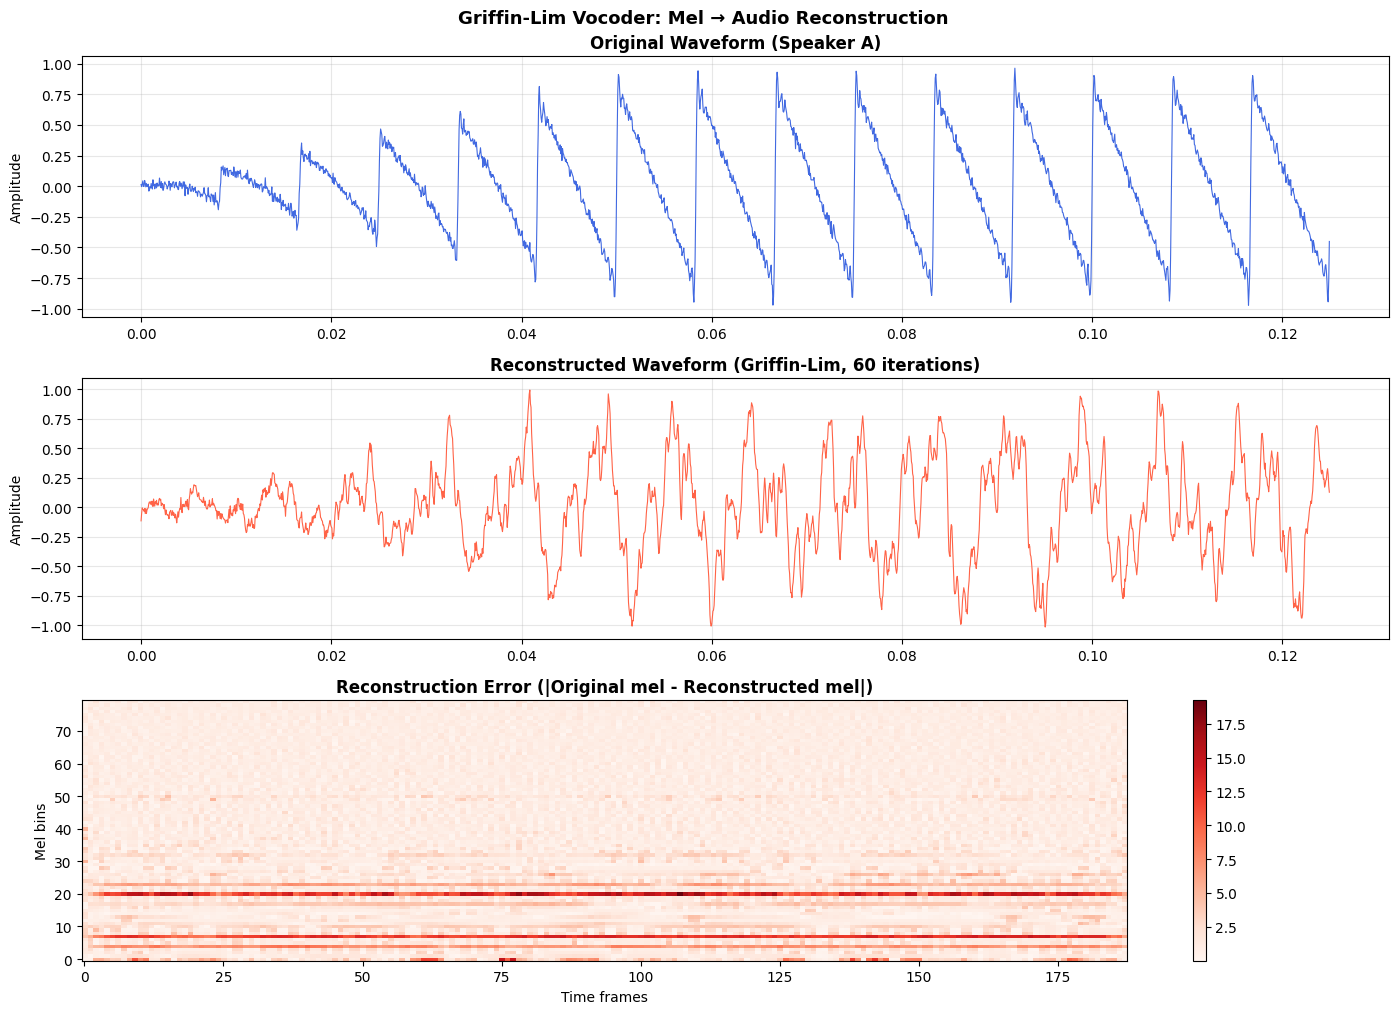


Mean reconstruction error (mel dB): 1.5956

💡 Griffin-Lim is good enough to verify the pipeline works.
   In production, use HiFi-GAN for high-quality output.


In [19]:
# ============================================================
# CELL 13: Griffin-Lim Vocoder — From Scratch
# ============================================================

def griffin_lim(mel_spectrogram, n_fft=1024, hop_length=256, win_length=1024,
                n_mels=80, sample_rate=16000, n_iter=60, fmin=0, fmax=8000):
    """
    Griffin-Lim phase reconstruction.
    
    Input: log mel spectrogram (n_mels, T)
    Output: audio waveform (samples,)
    """
    # Step 1: Invert log mel → linear power mel spectrogram
    mel_spec = np.exp(mel_spectrogram)  # Undo log: log(x) → x
    
    # Step 2: Invert mel filterbank → linear power spectrogram
    # librosa.feature.inverse.mel_to_stft does this
    # Mathematically: we apply pseudoinverse of the mel filterbank matrix
    stft_magnitude = librosa.feature.inverse.mel_to_stft(
        mel_spec, sr=sample_rate, n_fft=n_fft, fmin=fmin, fmax=fmax
    )  # Shape: (n_fft//2+1, T)
    
    # Step 3: Griffin-Lim iterative phase estimation
    # Initialize with random phase
    phase = np.exp(2j * np.pi * np.random.rand(*stft_magnitude.shape))
    angles = stft_magnitude * phase  # Complex spectrogram with random phase
    
    for i in range(n_iter):
        # iSTFT: complex spectrogram → time domain
        audio = librosa.istft(angles, hop_length=hop_length, win_length=win_length)
        
        # STFT: time domain → complex spectrogram (with updated phase)
        angles = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
        
        # Project: replace magnitude with target, keep estimated phase
        # np.angle extracts phase from complex number
        angles = stft_magnitude * np.exp(1j * np.angle(angles))
    
    # Final iSTFT to get audio
    audio = librosa.istft(angles, hop_length=hop_length, win_length=win_length)
    
    return audio


def mel_to_audio_librosa(mel_spectrogram, n_fft=1024, hop_length=256, 
                          n_mels=80, sample_rate=16000, n_iter=60):
    """Convenience wrapper using librosa's built-in Griffin-Lim"""
    mel_spec = np.exp(mel_spectrogram)  # Undo log
    audio = librosa.feature.inverse.mel_to_audio(
        mel_spec, sr=sample_rate, n_fft=n_fft, hop_length=hop_length,
        n_iter=n_iter
    )
    return audio


# Test: reconstruct Speaker A's audio from mel spectrogram
print("Testing Griffin-Lim reconstruction...")
print(f"Input mel spectrogram: {mel_A.shape}")

reconstructed_A = griffin_lim(
    mel_A, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
    n_mels=N_MELS, sample_rate=SAMPLE_RATE, n_iter=60
)

print(f"Reconstructed audio: {len(reconstructed_A)} samples = {len(reconstructed_A)/SAMPLE_RATE:.2f}s")

# Compare original vs reconstructed
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original waveform
t_orig = np.arange(len(speaker_A)) / SAMPLE_RATE
axes[0].plot(t_orig[:2000], speaker_A[:2000], 'royalblue', linewidth=0.8)
axes[0].set_title('Original Waveform (Speaker A)', fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Reconstructed waveform
t_rec = np.arange(len(reconstructed_A)) / SAMPLE_RATE
axes[1].plot(t_rec[:2000], reconstructed_A[:2000], 'tomato', linewidth=0.8)
axes[1].set_title('Reconstructed Waveform (Griffin-Lim, 60 iterations)', fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

# Compare mel spectrograms of original and reconstructed
min_len = min(len(speaker_A), len(reconstructed_A))
mel_reconstructed = librosa.feature.melspectrogram(
    y=reconstructed_A, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
)
mel_reconstructed_db = librosa.power_to_db(mel_reconstructed, ref=np.max)
mel_original_db = librosa.power_to_db(
    librosa.feature.melspectrogram(y=speaker_A, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS),
    ref=np.max
)

min_t = min(mel_reconstructed_db.shape[1], mel_original_db.shape[1])
error = np.abs(mel_original_db[:, :min_t] - mel_reconstructed_db[:, :min_t])
img = axes[2].imshow(error, aspect='auto', origin='lower', cmap='Reds')
axes[2].set_title('Reconstruction Error (|Original mel - Reconstructed mel|)', fontweight='bold')
axes[2].set_ylabel('Mel bins')
axes[2].set_xlabel('Time frames')
plt.colorbar(img, ax=axes[2])

plt.tight_layout()
plt.suptitle('Griffin-Lim Vocoder: Mel → Audio Reconstruction', y=1.01, fontsize=13, fontweight='bold')
plt.show()

print(f"\nMean reconstruction error (mel dB): {error.mean():.4f}")
print("\n💡 Griffin-Lim is good enough to verify the pipeline works.")
print("   In production, use HiFi-GAN for high-quality output.")

<a id='8'></a>
## 🚀 Section 8 — Putting It All Together: The Full Pipeline

### Complete Voice Cloning Flow

Now let's assemble everything into the complete pipeline:

```
1. REFERENCE AUDIO (5-10s clip of target speaker)
   → Compute MFCCs (Section 4)
   → Speaker Encoder (Section 5)
   → speaker_embedding ∈ ℝ¹²⁸

2. TEXT INPUT ("Hello, I am a voice cloning system")
   → Convert to character indices
   → Text Encoder (Section 6)
   → text_encoding ∈ ℝᵀˣ²⁵⁶

3. TTS SYNTHESIS
   → Decoder(text_encoding, speaker_embedding)
   → mel_spectrogram ∈ ℝ⁸⁰ˣᵀ'

4. VOCODER
   → Griffin-Lim(mel_spectrogram)
   → audio_waveform
```

Text to synthesize: 'Hello world this is voice cloning'
Reference speaker: Speaker A (f0=120Hz)
Stage 1: Extracting speaker embedding...
  Speaker embedding: torch.Size([1, 128]), L2 norm: 1.0000
Stage 2: Synthesizing mel spectrogram...
  Mel spectrogram: (80, 12) (n_mels × T_mel)
  Attention map: (12, 33) (T_mel × T_text)
Stage 3: Vocoding (Griffin-Lim)...
  Output audio: 2816 samples = 0.18s

✅ Audio saved to /tmp/cloned_voice.wav


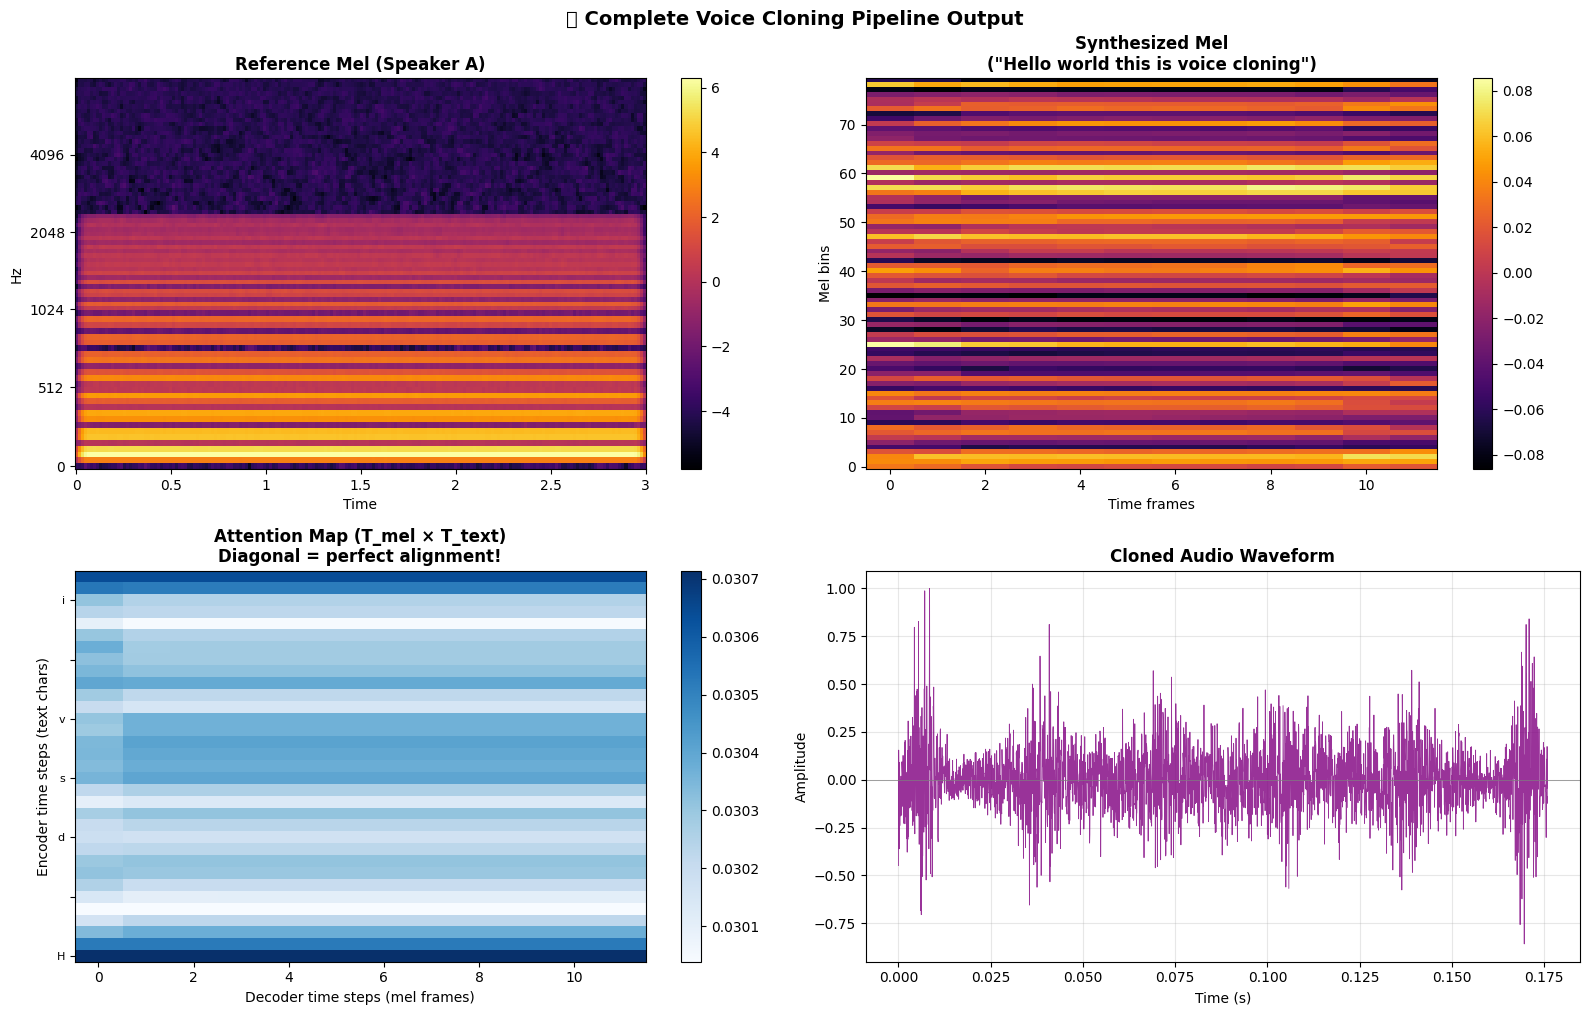


💡 The attention map should ideally be DIAGONAL (monotonic alignment).
   Non-diagonal attention = the model is confused about text-audio alignment.
   This is expected with an untrained model — needs real training data!


In [20]:
# ============================================================
# CELL 14: Complete Voice Cloning Pipeline
# ============================================================

class VoiceCloningPipeline:
    """
    End-to-end voice cloning pipeline.
    Combines Speaker Encoder + TTS Synthesizer + Vocoder.
    
    In production (SV2TTS / RTVC):
    - Speaker encoder: pretrained on 1000s of speakers
    - Synthesizer: fine-tuned on target domain data
    - Vocoder: WaveNet/HiFi-GAN
    """
    
    def __init__(self, speaker_encoder, tts_model, sample_rate=16000, 
                 n_mfcc=40, n_mels=80, n_fft=1024, hop_length=256):
        self.speaker_encoder = speaker_encoder.eval()
        self.tts_model = tts_model.eval()
        self.sample_rate = sample_rate
        self.n_mfcc = n_mfcc
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
    
    def extract_speaker_embedding(self, audio_clip):
        """
        Stage 1: Extract speaker embedding from reference audio.
        
        Args:
            audio_clip: numpy array of audio samples
        Returns:
            embedding: (1, embedding_dim) tensor
        """
        # Compute MFCCs
        mfccs = librosa.feature.mfcc(
            y=audio_clip, sr=self.sample_rate, 
            n_mfcc=self.n_mfcc, n_fft=self.n_fft, 
            hop_length=self.hop_length, n_mels=self.n_mels
        ).T  # (time, n_mfcc)
        
        # Pad or truncate to fixed length
        target_len = 100
        if len(mfccs) >= target_len:
            mfccs = mfccs[:target_len]
        else:
            pad = np.zeros((target_len - len(mfccs), self.n_mfcc))
            mfccs = np.vstack([mfccs, pad])
        
        # Convert to tensor and encode
        x = torch.FloatTensor(mfccs).unsqueeze(0)  # (1, time, n_mfcc)
        
        with torch.no_grad():
            embedding = self.speaker_encoder(x)  # (1, embedding_dim)
        
        return embedding
    
    def text_to_ids(self, text):
        """
        Stage 2: Convert text to character IDs.
        In production, you'd use phonemes instead of characters.
        Phonemes are more robust (same phoneme, different spellings).
        """
        # Simple ASCII encoding. In practice: use CMU Pronouncing Dictionary
        # or a G2P (grapheme-to-phoneme) model like espeak-phonemizer
        ids = [min(ord(c), 127) for c in text.lower()]
        return torch.LongTensor(ids).unsqueeze(0)  # (1, text_len)
    
    def synthesize(self, text, speaker_embedding, max_frames=300):
        """
        Stage 3: Synthesize mel spectrogram from text + speaker embedding.
        """
        text_ids = self.text_to_ids(text)
        
        with torch.no_grad():
            _, mel_post, stops, attn = self.tts_model(
                text_ids, speaker_embedding, mel_targets=None
            )
        
        mel = mel_post[0].numpy().T  # (n_mels, T_mel)
        attn = attn[0].numpy()       # (T_mel, T_text)
        
        return mel, attn
    
    def vocode(self, mel_spectrogram, n_iter=60):
        """
        Stage 4: Convert mel spectrogram → audio waveform.
        Uses Griffin-Lim (no neural vocoder needed for demonstration).
        """
        audio = mel_to_audio_librosa(
            mel_spectrogram, n_fft=self.n_fft, hop_length=self.hop_length,
            n_mels=self.n_mels, sample_rate=self.sample_rate, n_iter=n_iter
        )
        # Normalize output
        audio = audio / (np.max(np.abs(audio)) + 1e-8)
        return audio
    
    def clone_voice(self, reference_audio, text, n_iter=60):
        """
        Full pipeline: reference audio + text → cloned speech
        """
        print("Stage 1: Extracting speaker embedding...")
        speaker_emb = self.extract_speaker_embedding(reference_audio)
        print(f"  Speaker embedding: {speaker_emb.shape}, L2 norm: {torch.norm(speaker_emb):.4f}")
        
        print("Stage 2: Synthesizing mel spectrogram...")
        mel, attn = self.synthesize(text, speaker_emb)
        print(f"  Mel spectrogram: {mel.shape} (n_mels × T_mel)")
        print(f"  Attention map: {attn.shape} (T_mel × T_text)")
        
        print("Stage 3: Vocoding (Griffin-Lim)...")
        audio = self.vocode(mel, n_iter=n_iter)
        print(f"  Output audio: {len(audio)} samples = {len(audio)/self.sample_rate:.2f}s")
        
        return audio, mel, attn


# Create the pipeline
pipeline = VoiceCloningPipeline(encoder, tts_model)

# Clone Speaker A's voice saying a new sentence
test_text = "Hello world this is voice cloning"
print(f"Text to synthesize: '{test_text}'")
print(f"Reference speaker: Speaker A (f0=120Hz)")
print("=" * 50)

cloned_audio, cloned_mel, attn_map = pipeline.clone_voice(
    reference_audio=speaker_A,
    text=test_text
)

# Save the output
sf.write('/tmp/cloned_voice.wav', cloned_audio, SAMPLE_RATE)
print("\n✅ Audio saved to /tmp/cloned_voice.wav")

# Visualize the full pipeline outputs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Reference mel
ax = axes[0, 0]
img = librosa.display.specshow(mel_A, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                 x_axis='time', y_axis='mel', ax=ax, cmap='inferno')
ax.set_title('Reference Mel (Speaker A)', fontweight='bold')
plt.colorbar(img, ax=ax)

# 2. Synthesized mel
ax = axes[0, 1]
img = ax.imshow(cloned_mel, aspect='auto', origin='lower', cmap='inferno')
ax.set_title(f'Synthesized Mel\n("{test_text}")', fontweight='bold')
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel bins')
plt.colorbar(img, ax=ax)

# 3. Attention map
ax = axes[1, 0]
img = ax.imshow(attn_map.T, aspect='auto', origin='lower', cmap='Blues')
ax.set_title('Attention Map (T_mel × T_text)\nDiagonal = perfect alignment!', fontweight='bold')
ax.set_xlabel('Decoder time steps (mel frames)')
ax.set_ylabel('Encoder time steps (text chars)')
ax.set_yticks(range(0, len(test_text), 5))
ax.set_yticklabels(list(test_text)[::5], fontsize=8)
plt.colorbar(img, ax=ax)

# 4. Synthesized waveform
ax = axes[1, 1]
t = np.arange(len(cloned_audio)) / SAMPLE_RATE
ax.plot(t, cloned_audio, 'purple', linewidth=0.6, alpha=0.8)
ax.set_title('Cloned Audio Waveform', fontweight='bold')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.suptitle('🎙️ Complete Voice Cloning Pipeline Output', y=1.01, fontsize=14, fontweight='bold')
plt.show()

print("\n💡 The attention map should ideally be DIAGONAL (monotonic alignment).")
print("   Non-diagonal attention = the model is confused about text-audio alignment.")
print("   This is expected with an untrained model — needs real training data!")

<a id='9'></a>
## 🎓 Section 9 — Training Tips, Common Pitfalls & What's Next

### Key Lessons for Training from Scratch

**Speaker Encoder:**
- Need **diverse speakers** (1000+) for generalization. LibriSpeech has 2484 speakers.
- Train for 3M+ steps. This takes days on a single GPU.
- Monitor cosine similarity histograms: same-speaker pairs should have high similarity (~0.7-0.9), cross-speaker pairs should have low similarity (~0.1-0.3).
- Harder triplets → better models. Use "semi-hard" mining: find negatives that are similar to anchor but not so close the model already handles them.

**TTS Synthesizer:**
- The most common failure: **attention doesn't learn**. The model generates garbled audio because it can't align text with audio.
- Fix: use guided attention loss (penalize non-diagonal attention during early training).
- Curriculum: start with short sentences (5-10 chars), gradually increase length.
- Learning rate: start at 1e-3, use a warmup schedule for the first 1000 steps.
- **100 hours of high-quality speech** is the minimum for decent quality (LJSpeech: 24h single speaker, VCTK: 44h multi-speaker).

**Vocoder:**
- Griffin-Lim is great for debugging but sounds metallic in production.
- Use WaveGlow or HiFi-GAN for production quality.
- Train the vocoder SEPARATELY on the same mel spectrograms the synthesizer produces.

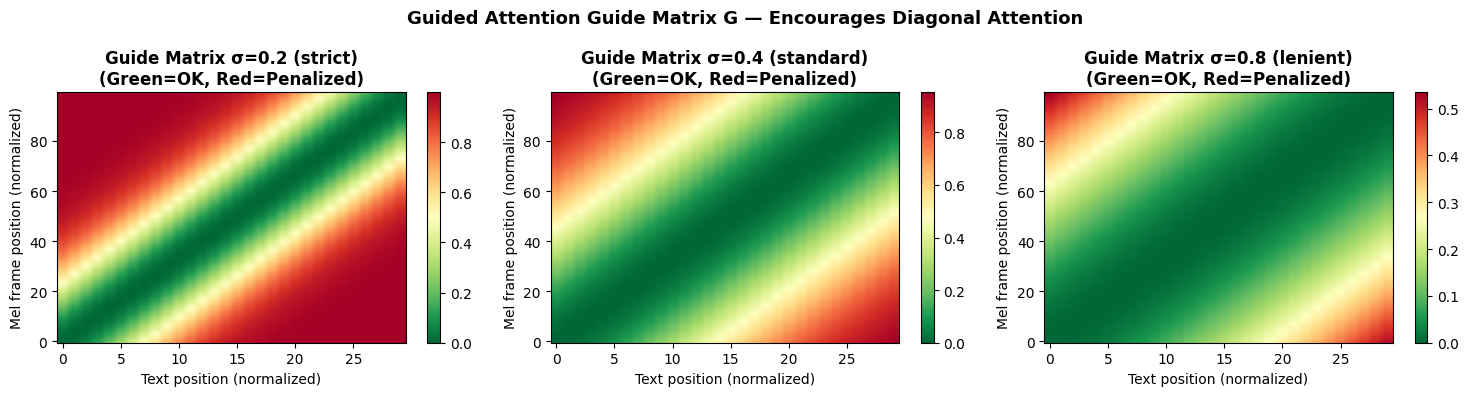

Guided attention loss test:
  Guided loss for PERFECT (diagonal) attention: 0.000033
  Guided loss for RANDOM attention:             0.010580
  ✅ Perfect attention has LOWER loss — exactly what we want!


In [21]:
# ============================================================
# CELL 15: Guided Attention Loss — Fixing Attention Alignment
# This is one of the most important practical tricks for TTS training
# ============================================================

class GuidedAttentionLoss(nn.Module):
    """
    Guided Attention Loss (Tachibana et al., 2017).
    
    Problem: Early in training, attention is random → audio is garbled.
    Without guidance, it can take 100k+ steps for attention to converge.
    
    Solution: Add a loss term that EXPLICITLY encourages diagonal attention.
    Create a "guide" matrix G where G[t, n] = 1 - exp(-(n/N - t/T)² / (2σ²))
    G is SMALL along the diagonal and LARGE off-diagonal.
    Minimize: mean(attention * G) → pushes attention toward diagonal.
    
    Anneal σ: Start with large σ (allow wide attention), shrink as training progresses.
    """
    
    def __init__(self, sigma=0.4):
        """
        sigma: Width of the diagonal band we allow. 
               Larger σ = more lenient (wide band).
               Smaller σ = stricter (narrow diagonal only).
               Typical schedule: start σ=0.4, end σ=0.2
        """
        super().__init__()
        self.sigma = sigma
    
    def _guide_matrix(self, T_mel, T_text, sigma):
        """
        Create the attention guide matrix G of shape (T_mel, T_text).
        G is close to 1 OFF the diagonal, 0 ON the diagonal.
        """
        # Create normalized coordinates
        mel_idx = torch.arange(T_mel, dtype=torch.float32) / T_mel  # [0, 1]
        text_idx = torch.arange(T_text, dtype=torch.float32) / T_text  # [0, 1]
        
        # Broadcasting: shape (T_mel, T_text)
        mel_idx = mel_idx.unsqueeze(1)    # (T_mel, 1)
        text_idx = text_idx.unsqueeze(0)  # (1, T_text)
        
        # Gaussian centered on diagonal
        # G[t, n] = 0 when t/T_mel == n/T_text (on diagonal)
        # G[t, n] → 1 when far from diagonal
        G = 1 - torch.exp(-(mel_idx - text_idx)**2 / (2 * sigma**2))
        return G
    
    def forward(self, attention_weights, T_mel=None, T_text=None):
        """
        Args:
            attention_weights: (batch, T_mel, T_text)
        Returns:
            loss: scalar
        """
        batch, T_mel, T_text = attention_weights.shape
        G = self._guide_matrix(T_mel, T_text, self.sigma)  # (T_mel, T_text)
        
        # Penalize attention weight at off-diagonal positions
        loss = (attention_weights * G.unsqueeze(0)).mean()
        return loss


# Visualize the guide matrix
guided_loss = GuidedAttentionLoss(sigma=0.4)

T_mel, T_text = 100, 30
G = guided_loss._guide_matrix(T_mel, T_text, sigma=0.4).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sigma, title in zip(axes, [0.2, 0.4, 0.8], ['σ=0.2 (strict)', 'σ=0.4 (standard)', 'σ=0.8 (lenient)']):
    G_plot = guided_loss._guide_matrix(T_mel, T_text, sigma=sigma).numpy()
    img = ax.imshow(G_plot, aspect='auto', origin='lower', cmap='RdYlGn_r')
    ax.set_title(f'Guide Matrix {title}\n(Green=OK, Red=Penalized)', fontweight='bold')
    ax.set_xlabel('Text position (normalized)')
    ax.set_ylabel('Mel frame position (normalized)')
    plt.colorbar(img, ax=ax)

plt.suptitle('Guided Attention Guide Matrix G — Encourages Diagonal Attention', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Guided attention loss test:")
# Test with a synthetic attention map
# Case 1: Perfect diagonal attention
perfect_attn = torch.zeros(2, T_mel, T_text)
for i in range(T_mel):
    j = min(int(i * T_text / T_mel), T_text - 1)
    perfect_attn[:, i, j] = 1.0

# Case 2: Random attention (bad)
random_attn = F.softmax(torch.randn(2, T_mel, T_text), dim=-1)

loss_perfect = guided_loss(perfect_attn)
loss_random = guided_loss(random_attn)

print(f"  Guided loss for PERFECT (diagonal) attention: {loss_perfect:.6f}")
print(f"  Guided loss for RANDOM attention:             {loss_random:.6f}")
print(f"  ✅ Perfect attention has LOWER loss — exactly what we want!")

In [22]:
# ============================================================
# CELL 16: Interview Cheat Sheet — Key Concepts Summary
# ============================================================

cheat_sheet = """
╔══════════════════════════════════════════════════════════════════╗
║          VOICE CLONING — INTERVIEW CHEAT SHEET                  ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is a spectrogram?                                        ║
║ A: A 2D representation of audio where the x-axis is time and    ║
║    the y-axis is frequency. Each pixel intensity = how much of  ║
║    that frequency exists at that time. Created via STFT.        ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: Why mel scale?                                               ║
║ A: Human hearing is logarithmic. The mel scale (mel = 2595 *    ║
║    log10(1 + f/700)) mimics this: we have more resolution at    ║
║    low frequencies than high ones. Same as our ears.            ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What do MFCCs capture?                                       ║
║ A: The slowly-varying spectral ENVELOPE (vocal tract shape).    ║
║    DCT decorrelates mel spectrogram features. Low-order MFCCs   ║
║    capture broad spectral shape (speaker identity, vowels).     ║
║    High-order capture fine details (usually discarded).         ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is a speaker embedding?                                 ║
║ A: A fixed-size vector representing a speaker's unique voice    ║
║    characteristics, learned by training a speaker encoder with  ║
║    triplet or GE2E loss. Same speaker → close vectors in        ║
║    embedding space. Different speakers → distant vectors.       ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: Why L2 normalize embeddings?                                 ║
║ A: Projects to unit hypersphere. Cosine similarity = dot        ║
║    product (fast). Only direction matters, not magnitude.       ║
║    Reduces scaling issues in clustering/comparison.             ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is teacher forcing?                                     ║
║ A: During TTS training, feed the GROUND TRUTH previous mel      ║
║    frame to the decoder instead of its own prediction.          ║
║    Prevents error accumulation in auto-regressive training.     ║
║    Train-inference gap → use scheduled sampling or PreNet dropout║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is attention in TTS? Why location-sensitive?            ║
║ A: Attention decides which text characters to focus on at each  ║
║    audio frame. Location-sensitive also looks at previous       ║
║    attention → enforces monotonic left-to-right progression     ║
║    (speech is always said left-to-right, never jumps back).     ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is Griffin-Lim?                                         ║
║ A: An iterative algorithm to estimate audio phase from a        ║
║    magnitude spectrogram. Alternates between time-domain and    ║
║    frequency-domain projections. Classic but has buzzy quality. ║
║    Production uses neural vocoders (WaveNet, HiFi-GAN).         ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is guided attention loss?                               ║
║ A: An auxiliary loss that penalizes off-diagonal attention.     ║
║    Explicitly encourages the model to align text and audio      ║
║    monotonically during early training.                         ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What's the difference between Tacotron2 and FastSpeech2?     ║
║ A: Tacotron2 is auto-regressive (slow, frame by frame).         ║
║    FastSpeech2 uses a duration predictor to generate all frames ║
║    in parallel (no attention, no auto-regression → much faster).║
║    FastSpeech2 is now the standard for production TTS.          ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is zero-shot voice cloning?                             ║
║ A: Cloning a NEVER-SEEN speaker from just a few seconds of      ║
║    audio — no fine-tuning needed. Requires a powerful speaker   ║
║    encoder trained on thousands of diverse speakers so it        ║
║    generalizes to any new speaker at inference time.            ║
╚══════════════════════════════════════════════════════════════════╝
"""

print(cheat_sheet)


╔══════════════════════════════════════════════════════════════════╗
║          VOICE CLONING — INTERVIEW CHEAT SHEET                  ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What is a spectrogram?                                        ║
║ A: A 2D representation of audio where the x-axis is time and    ║
║    the y-axis is frequency. Each pixel intensity = how much of  ║
║    that frequency exists at that time. Created via STFT.        ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: Why mel scale?                                               ║
║ A: Human hearing is logarithmic. The mel scale (mel = 2595 *    ║
║    log10(1 + f/700)) mimics this: we have more resolution at    ║
║    low frequencies than high ones. Same as our ears.            ║
╠══════════════════════════════════════════════════════════════════╣
║ Q: What do MFCCs capture?                                       ║
║ A: The slowly-varying spectral ENVELOPE 

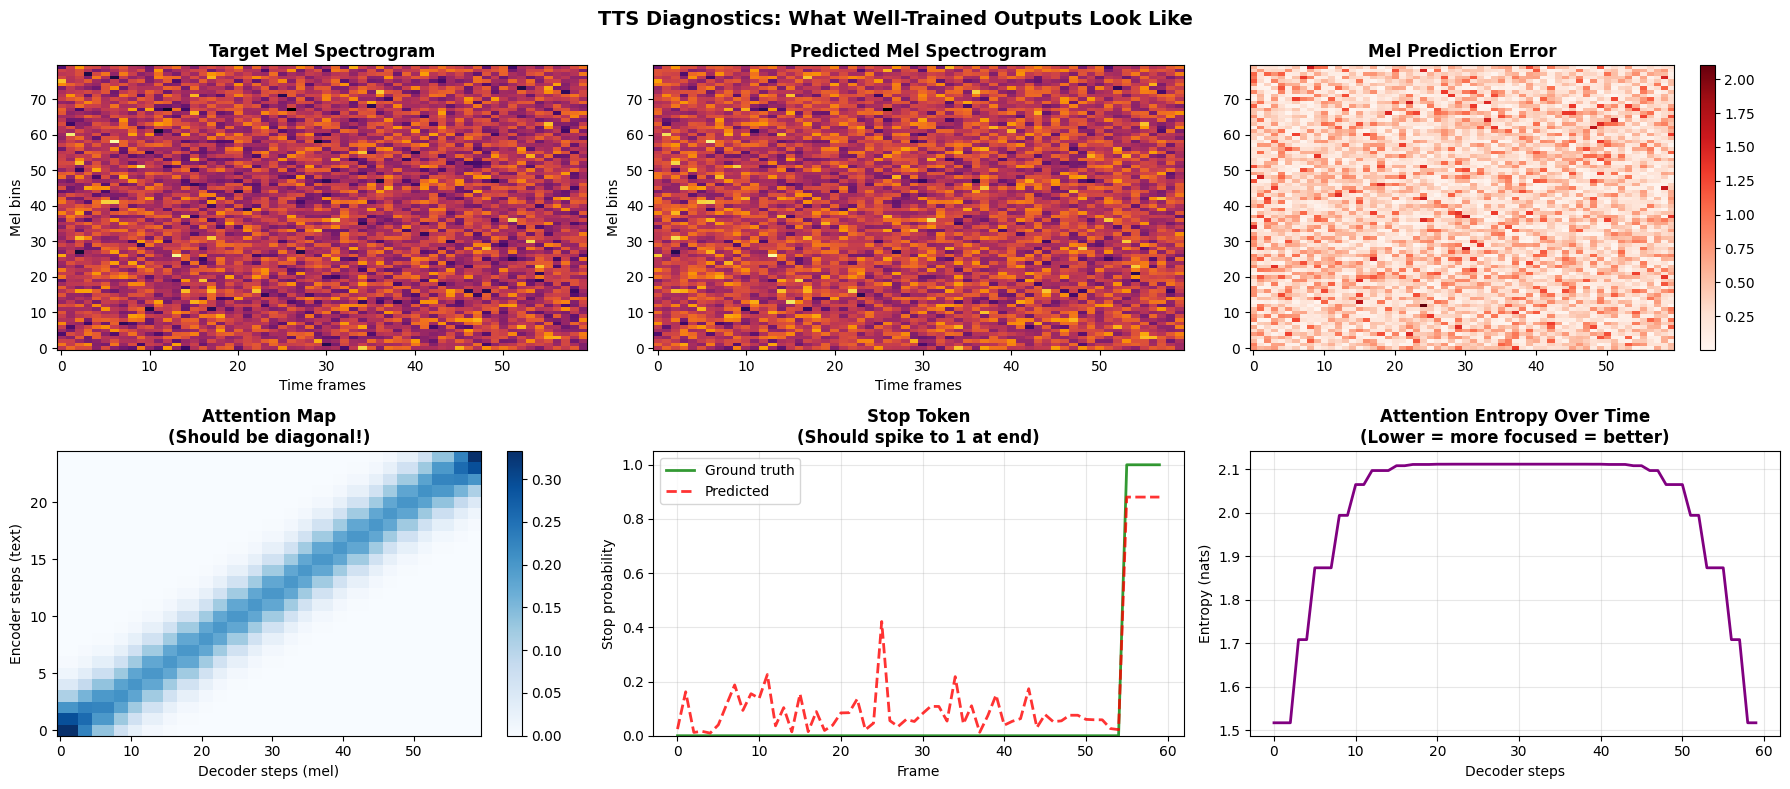

In [23]:
# ============================================================
# CELL 17: Diagnostic Plots — How to Debug a TTS System
# When training breaks, these are the first things to check
# ============================================================

def plot_diagnostics(mel_target, mel_predicted, attention, stop_targets, stop_preds, title="Training Diagnostics"):
    """
    Standard diagnostic plot for TTS systems.
    What to look for:
    1. Mel alignment: predicted should look similar to target
    2. Attention: should be roughly diagonal (monotonic text→audio alignment)
    3. Stop token: should be 0 throughout, spike to 1 at the end
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    
    # 1. Target mel spectrogram
    ax = axes[0, 0]
    ax.imshow(mel_target, aspect='auto', origin='lower', cmap='inferno')
    ax.set_title('Target Mel Spectrogram', fontweight='bold')
    ax.set_xlabel('Time frames'); ax.set_ylabel('Mel bins')
    
    # 2. Predicted mel spectrogram
    ax = axes[0, 1]
    ax.imshow(mel_predicted, aspect='auto', origin='lower', cmap='inferno')
    ax.set_title('Predicted Mel Spectrogram', fontweight='bold')
    ax.set_xlabel('Time frames'); ax.set_ylabel('Mel bins')
    
    # 3. Prediction error
    ax = axes[0, 2]
    min_t = min(mel_target.shape[1], mel_predicted.shape[1])
    error = np.abs(mel_target[:, :min_t] - mel_predicted[:, :min_t])
    img = ax.imshow(error, aspect='auto', origin='lower', cmap='Reds')
    ax.set_title('Mel Prediction Error', fontweight='bold')
    plt.colorbar(img, ax=ax)
    
    # 4. Attention map
    ax = axes[1, 0]
    img = ax.imshow(attention.T, aspect='auto', origin='lower', cmap='Blues')
    ax.set_title('Attention Map\n(Should be diagonal!)', fontweight='bold')
    ax.set_xlabel('Decoder steps (mel)'); ax.set_ylabel('Encoder steps (text)')
    plt.colorbar(img, ax=ax)
    
    # 5. Stop token
    ax = axes[1, 1]
    t = np.arange(len(stop_targets))
    ax.plot(t, stop_targets, 'g-', linewidth=2, label='Ground truth', alpha=0.8)
    ax.plot(t[:len(stop_preds)], 
            torch.sigmoid(torch.FloatTensor(stop_preds)).numpy(), 
            'r--', linewidth=2, label='Predicted', alpha=0.8)
    ax.set_title('Stop Token\n(Should spike to 1 at end)', fontweight='bold')
    ax.set_xlabel('Frame'); ax.set_ylabel('Stop probability')
    ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, alpha=0.3)
    
    # 6. Attention entropy over time
    ax = axes[1, 2]
    entropy = -np.sum(attention * np.log(attention + 1e-8), axis=1)
    ax.plot(entropy, 'purple', linewidth=2)
    ax.set_title('Attention Entropy Over Time\n(Lower = more focused = better)', fontweight='bold')
    ax.set_xlabel('Decoder steps'); ax.set_ylabel('Entropy (nats)')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Create synthetic diagnostic data (what you'd see during training)
T_mel_diag, T_text_diag = 60, 25

# Simulate an "improving" attention (partially diagonal)
attn_diag = np.zeros((T_mel_diag, T_text_diag))
for i in range(T_mel_diag):
    j_center = int(i * T_text_diag / T_mel_diag)
    for j in range(T_text_diag):
        attn_diag[i, j] = np.exp(-0.5 * (j - j_center)**2 / 4)  # Gaussian around diagonal
attn_diag = attn_diag / attn_diag.sum(axis=1, keepdims=True)  # Normalize

# Simulated mel spectrograms
mel_tgt_diag = np.random.randn(N_MELS, T_mel_diag) * 2
mel_pred_diag = mel_tgt_diag + 0.5 * np.random.randn(*mel_tgt_diag.shape)

# Stop targets
stop_tgt = np.zeros(T_mel_diag)
stop_tgt[-5:] = 1.0
stop_pred = np.random.randn(T_mel_diag) - 3  # Low logits = predict "continue"
stop_pred[-5:] = 2.0  # High logits at end = predict "stop"

plot_diagnostics(
    mel_tgt_diag, mel_pred_diag, attn_diag, 
    stop_tgt, stop_pred,
    title="TTS Diagnostics: What Well-Trained Outputs Look Like"
)

In [24]:
# ============================================================
# CELL 18: What's Next? — Path to Production Quality
# ============================================================

roadmap = """
╔═══════════════════════════════════════════════════════════╗
║        YOUR VOICE CLONING LEARNING ROADMAP               ║
╠═══════════════════════════════════════════════════════════╣
║ ✅ PHASE 1 (YOU ARE HERE): Understand the fundamentals   ║
║    - Audio signal processing (STFT, mel, MFCCs)          ║
║    - Speaker embeddings & metric learning                ║
║    - Encoder-decoder TTS with attention                  ║
║    - Griffin-Lim vocoder                                 ║
╠═══════════════════════════════════════════════════════════╣
║ 🔜 PHASE 2: Real Data + Real Training                   ║
║    Dataset: LJSpeech (24h, 1 speaker, free)              ║
║    Dataset: VCTK (44h, 109 speakers)                     ║
║    Dataset: LibriTTS (245h, 2456 speakers)               ║
║    Train the encoder for speaker verification first      ║
║    Check EER (Equal Error Rate) as your eval metric      ║
╠═══════════════════════════════════════════════════════════╣
║ 🔜 PHASE 3: Pretrained Models & Fine-Tuning             ║
║    Clone SV2TTS/RTVC (Real-Time Voice Cloning on GitHub) ║
║    Understand Tacotron2 pretrained checkpoint            ║
║    Fine-tune on your target speaker (5-10 min audio)     ║
║    Use HiFi-GAN vocoder for production quality           ║
╠═══════════════════════════════════════════════════════════╣
║ 🔜 PHASE 4: Modern Architectures                        ║
║    FastSpeech2: parallel, faster, more controllable      ║
║    VITS: end-to-end (text → audio in one model)          ║
║    YourTTS: few-shot voice cloning with VITS             ║
║    Tortoise-TTS: diffusion-based, highest quality        ║
║    VALL-E: language model approach (zero-shot cloning)   ║
╠═══════════════════════════════════════════════════════════╣
║ 📚 MUST-READ PAPERS:                                     ║
║    1. "Tacotron" (Wang et al., 2017) — original TTS      ║
║    2. "Tacotron 2" (Shen et al., 2018)                   ║
║    3. "SV2TTS" (Jia et al., 2018) — voice cloning paper  ║
║    4. "FastSpeech 2" (Ren et al., 2020)                  ║
║    5. "HiFi-GAN" (Kong et al., 2020)                     ║
║    6. "VITS" (Kim et al., 2021)                          ║
║    7. "VALL-E" (Wang et al., 2023)                       ║
╠═══════════════════════════════════════════════════════════╣
║ 🛠️ KEY TOOLS:                                           ║
║    librosa    — audio processing                         ║
║    torchaudio — PyTorch audio transforms                 ║
║    speechbrain — speech ML framework                     ║
║    coqui-ai/TTS — production TTS with 1100+ voices       ║
║    espeak-ng  — G2P (graphemes to phonemes)              ║
║    resemblyzer — pretrained speaker encoder (SV2TTS)     ║
╚═══════════════════════════════════════════════════════════╝
"""
print(roadmap)

print("\n🎉 CONGRATULATIONS!")
print("You now understand voice cloning from first principles!")
print("You can explain:")
print("  ✅ How raw audio becomes a mel spectrogram (STFT → mel filterbank → log)")
print("  ✅ What MFCCs are and why they capture speaker identity")
print("  ✅ How speaker encoders learn embeddings using metric learning")
print("  ✅ The encoder-decoder TTS architecture with attention")
print("  ✅ Teacher forcing and why it matters")
print("  ✅ How Griffin-Lim converts spectrograms back to audio")
print("  ✅ What guided attention loss does")
print("  ✅ The complete three-module voice cloning pipeline")


╔═══════════════════════════════════════════════════════════╗
║        YOUR VOICE CLONING LEARNING ROADMAP               ║
╠═══════════════════════════════════════════════════════════╣
║ ✅ PHASE 1 (YOU ARE HERE): Understand the fundamentals   ║
║    - Audio signal processing (STFT, mel, MFCCs)          ║
║    - Speaker embeddings & metric learning                ║
║    - Encoder-decoder TTS with attention                  ║
║    - Griffin-Lim vocoder                                 ║
╠═══════════════════════════════════════════════════════════╣
║ 🔜 PHASE 2: Real Data + Real Training                   ║
║    Dataset: LJSpeech (24h, 1 speaker, free)              ║
║    Dataset: VCTK (44h, 109 speakers)                     ║
║    Dataset: LibriTTS (245h, 2456 speakers)               ║
║    Train the encoder for speaker verification first      ║
║    Check EER (Equal Error Rate) as your eval metric      ║
╠═══════════════════════════════════════════════════════════╣
║ 🔜 PHASE 3: Pretraine